# Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
import warnings
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import time
import itertools
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [ ]:
warnings.filterwarnings('ignore')

# Loading Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/MyDrive/ml_project')

In [ ]:
print(os.listdir())

['all_entity_info.txt', 'README.md', 'KG20C_graph.png', 'valid.txt', 'test.txt', 'train.txt', 'all_relation_info.txt', 'archive.zip', 'entities.csv', 'train.csv', 'test.csv', 'valid.csv', 'relations.csv', 'kg20c_df.csv', 'kg20c_df_renamed.csv']


# Data Preprocessing

In [ ]:
pd.read_csv("all_entity_info.txt", sep="\t", header=None).to_csv("entities.csv", index=False)

# Convert relation file
pd.read_csv("all_relation_info.txt", sep="\t", header=None).to_csv("relations.csv", index=False)

# Convert triples
pd.read_csv("train.txt", sep="\t", header=None).to_csv("train.csv", index=False)

pd.read_csv("valid.txt", sep="\t", header=None).to_csv("valid.csv", index=False)

pd.read_csv("test.txt", sep="\t", header=None).to_csv("test.csv", index=False)

print("text files are converted to csv files.")

text files are converted to csv files.


In [ ]:
train_ds = pd.read_csv("train.csv")
valid_ds = pd.read_csv("valid.csv")
test_ds  = pd.read_csv("test.csv")

train_ds["split"] = "train"
valid_ds["split"] = "valid"
test_ds["split"]  = "test"

In [ ]:
df = pd.concat([train_ds, valid_ds, test_ds], ignore_index=True)
mydf = df.to_csv("kg20c_df.csv", index=False)
print("Total triples:", len(df))

Total triples: 55607


In [ ]:
dataframe = pd.read_csv("kg20c_df.csv")
dataframe.columns

Index(['0', '1', '2', 'split'], dtype='object')

In [ ]:
dataframe.columns = ["head_entity", "relation", "tail_entity", "split"]

dataframe.to_csv("kg20c_df_renamed.csv", index=False)

print("Columns renamed successfully")
print(dataframe.columns)

dataframe.head()

Columns renamed successfully
Index(['head_entity', 'relation', 'tail_entity', 'split'], dtype='object')


,head_entity,relation,tail_entity,split
0,28674CFA,author_in_affiliation,075CFC38,train
1,062B7298,author_in_affiliation,00D4F325,train
2,8032D24C,author_write_paper,7E3C8A87,train
3,7B1FB61F,author_write_paper,770D962D,train
4,7F720D06,paper_cite_paper,6B51598C,train


In [ ]:
dataframe.info()
print("Missing values per column:")
dataframe.isnull().sum()

duplicates = dataframe.duplicated(subset=["head_entity","relation","tail_entity"])

print("\n Number of duplicate triples:", duplicates.sum())
print("\nNo missing values in the dataset, no dropping or filling rows necessary")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55607 entries, 0 to 55606
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   head_entity  55607 non-null  object
 1   relation     55607 non-null  object
 2   tail_entity  55607 non-null  object
 3   split        55607 non-null  object
dtypes: object(4)
memory usage: 1.7+ MB
Missing values per column:

 Number of duplicate triples: 0

No missing values in the dataset, no dropping or filling rows necessary


# Data Normalization

In [ ]:
dataframe.dtypes

,0
head_entity,object
relation,object
tail_entity,object
split,object


In [ ]:
for col in ["head_entity", "relation", "tail_entity"]:
    dataframe[col] = dataframe[col].astype(str)
    dataframe[col] = dataframe[col].str.strip()
    dataframe[col] = dataframe[col].str.lower()

In [ ]:
# index encoding
head_entities = sorted(dataframe["head_entity"].unique())
tail_entities = sorted(dataframe["tail_entity"].unique())
relations = sorted(dataframe["relation"].unique())

In [ ]:
# combine head and tail entities
entities = sorted(set(head_entities).union(set(tail_entities)))

In [ ]:
entity2id = {e: i for i, e in enumerate(entities)}
relation2id = {r: i for i, r in enumerate(relations)}

dataframe["h_id"] = dataframe["head_entity"].map(entity2id)
dataframe["r_id"] = dataframe["relation"].map(relation2id)
dataframe["t_id"] = dataframe["tail_entity"].map(entity2id)

In [ ]:
dataframe.head()

,head_entity,relation,tail_entity,split,h_id,r_id,t_id
0,28674cfa,author_in_affiliation,075cfc38,train,3877,0,1915
1,062b7298,author_in_affiliation,00d4f325,train,1603,0,229
2,8032d24c,author_write_paper,7e3c8a87,train,12953,1,10004
3,7b1fb61f,author_write_paper,770d962d,train,7398,1,5957
4,7f720d06,paper_cite_paper,6b51598c,train,11891,2,4979


In [ ]:
dataframe.isnull().sum()

,0
head_entity,0
relation,0
tail_entity,0
split,0
h_id,0
r_id,0
t_id,0


# Annotation/Labeling

In [ ]:
dataframe["label"] = 1
dataframe.head()

,head_entity,relation,tail_entity,split,h_id,r_id,t_id,label
0,28674cfa,author_in_affiliation,075cfc38,train,3877,0,1915,1
1,062b7298,author_in_affiliation,00d4f325,train,1603,0,229,1
2,8032d24c,author_write_paper,7e3c8a87,train,12953,1,10004,1
3,7b1fb61f,author_write_paper,770d962d,train,7398,1,5957,1
4,7f720d06,paper_cite_paper,6b51598c,train,11891,2,4979,1


In [ ]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55607 entries, 0 to 55606
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   head_entity  55607 non-null  object
 1   relation     55607 non-null  object
 2   tail_entity  55607 non-null  object
 3   split        55607 non-null  object
 4   h_id         55607 non-null  int64 
 5   r_id         55607 non-null  int64 
 6   t_id         55607 non-null  int64 
 7   label        55607 non-null  int64 
dtypes: int64(4), object(4)
memory usage: 3.4+ MB


In [ ]:
all_triples = set(zip(dataframe["h_id"],dataframe["r_id"],dataframe["t_id"]))

entity_ids = list(set(dataframe["h_id"]).union(set(dataframe["t_id"])))

neg_samples = []

In [ ]:
for h, r, t in all_triples:

    # randomly decide whether to corrupt head or tail
    if random.random() < 0.5:
        # corrupt head
        h_neg = random.choice(entity_ids)
        candidate = (h_neg, r, t)
    else:
        # corrupt tail
        t_neg = random.choice(entity_ids)
        candidate = (h, r, t_neg)

    # filtered setting
    while candidate in all_triples:
        if random.random() < 0.5:
            h_neg = random.choice(entity_ids)
            candidate = (h_neg, r, t)
        else:
            t_neg = random.choice(entity_ids)
            candidate = (h, r, t_neg)

    neg_samples.append((*candidate, 0))  # label = 0

In [ ]:
neg_df = pd.DataFrame(neg_samples, columns=["h_id","r_id","t_id","label"])

In [ ]:
pos_df = dataframe[["h_id","r_id","t_id","label"]]

full_dataset = pd.concat([pos_df, neg_df], ignore_index=True)

print("Final dataset size:", len(full_dataset))
print(full_dataset["label"].value_counts())

Final dataset size: 111214
label
1    55607
0    55607
Name: count, dtype: int64


In [ ]:
full_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111214 entries, 0 to 111213
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   h_id    111214 non-null  int64
 1   r_id    111214 non-null  int64
 2   t_id    111214 non-null  int64
 3   label   111214 non-null  int64
dtypes: int64(4)
memory usage: 3.4 MB


In [ ]:
full_dataset.head()

,h_id,r_id,t_id,label
0,3877,0,1915,1
1,1603,0,229,1
2,12953,1,10004,1
3,7398,1,5957,1
4,11891,2,4979,1


# Exploratory Data Analysis

In [ ]:
print("Basic Statistics for the Dataset: ")

num_samples = len(dataframe)
num_entities = len(set(dataframe["head_entity"]).union(set(dataframe["tail_entity"])))
num_relations = dataframe["relation"].nunique()

print("Total triples:", num_samples)
print("Total unique entities:", num_entities)
print("Total unique relations:", num_relations)

print("\nSplits distribution:")
print(dataframe["split"].value_counts())

Basic Statistics for the Dataset: 
Total triples: 55607
Total unique entities: 16362
Total unique relations: 5

Splits distribution:
split
train    48213
test      3724
valid     3670
Name: count, dtype: int64


Relation Distribution
relation
paper_in_domain          20637
author_write_paper       14096
paper_cite_paper          8583
author_in_affiliation     7244
paper_in_venue            5047
Name: count, dtype: int64


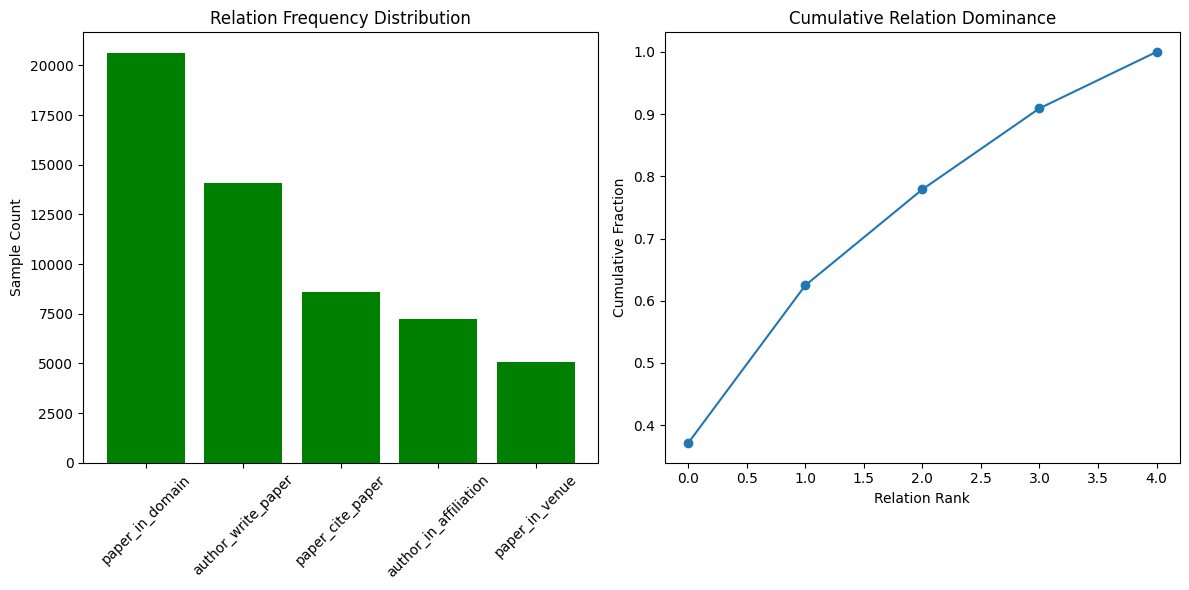

In [ ]:
print("Relation Distribution")
relation_counts = dataframe["relation"].value_counts()
print(relation_counts)


fig, axes = plt.subplots(1, 2, figsize=(12,6))

axes[0].bar(relation_counts.index.astype(str), relation_counts.values, color="green")
axes[0].set_title("Relation Frequency Distribution")
axes[0].set_ylabel("Sample Count")
axes[0].tick_params(axis="x", rotation=45)

rel_cum = relation_counts.cumsum() / relation_counts.sum()
axes[1].plot(rel_cum.values, marker="o")
axes[1].set_title("Cumulative Relation Dominance")
axes[1].set_xlabel("Relation Rank")
axes[1].set_ylabel("Cumulative Fraction")

plt.tight_layout()
plt.show()

Relation Distribution per Split (Train / Test / Valid)


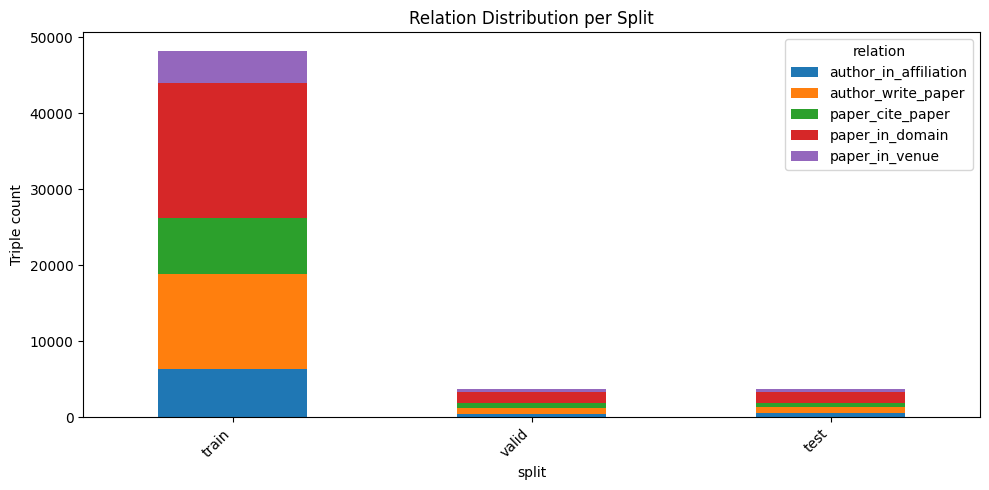

In [ ]:
print("Relation Distribution per Split (Train / Test / Valid)")
if {'train','valid','test'}.issubset(set(dataframe['split'].unique())):
    split_rel = dataframe.groupby(['split','relation']).size().unstack(fill_value=0).loc[['train','valid','test']]
    split_rel.plot(kind='bar', stacked=True, figsize=(10,5))
    plt.title("Relation Distribution per Split")
    plt.ylabel("Triple count")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Entity Degree Distribution
count    16362.000000
mean         3.480137
std          5.998564
min          0.000000
50%          0.000000
75%          7.000000
90%         13.000000
95%         15.000000
99%         22.000000
max         74.000000
Name: count, dtype: float64


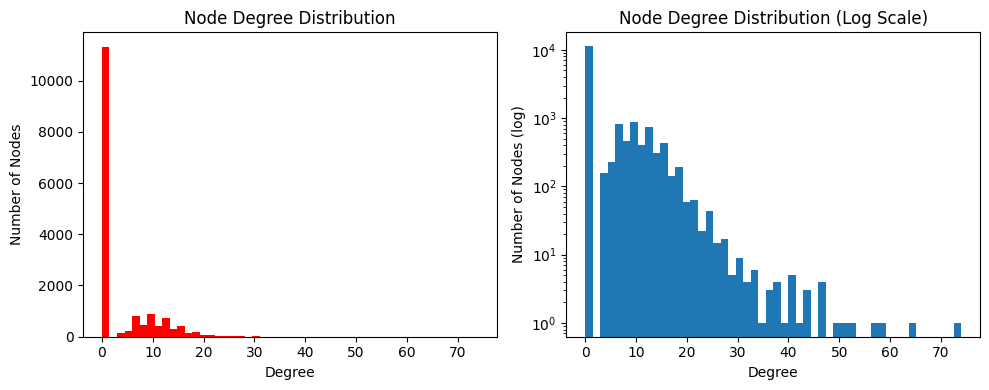

In [ ]:
print("Entity Degree Distribution")
entity_degree = (dataframe["h_id"].value_counts() + dataframe["t_id"].value_counts()).fillna(0)

print(entity_degree.describe(percentiles=[.5,.75,.9,.95,.99]))

fig, axes = plt.subplots(1, 2, figsize=(10,4))

# Normal histogram
axes[0].hist(entity_degree.values, bins=50, color='red')
axes[0].set_title("Node Degree Distribution")
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("Number of Nodes")

# Log-scale histogram
axes[1].hist(entity_degree.values, bins=50, log=True)
axes[1].set_title("Node Degree Distribution (Log Scale)")
axes[1].set_xlabel("Degree")
axes[1].set_ylabel("Number of Nodes (log)")

plt.tight_layout()
plt.show()

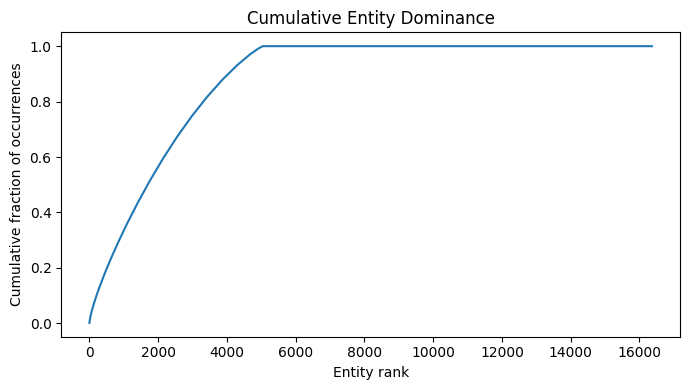

In [ ]:
deg_sorted = entity_degree.sort_values(ascending=False)
cum = deg_sorted.cumsum() / deg_sorted.sum()

plt.figure(figsize=(7,4))
plt.plot(cum.values)
plt.title("Cumulative Entity Dominance")
plt.xlabel("Entity rank")
plt.ylabel("Cumulative fraction of occurrences")
plt.tight_layout()
plt.show()


Top 10 head entities:
head_entity
7fc7e48c    57
7f8038ba    48
812ff69e    46
7d6e9ef4    42
11ba75da    38
7bbc933b    38
7e7a3a69    37
758ec809    35
7f08f36e    32
7e8ea464    27
Name: count, dtype: int64

Top 10 tail entities:
tail_entity
43319dd4    738
465f7c62    636
45701bf3    612
0724dfba    434
0765a2e4    363
4ce6fc2d    333
43fd776c    314
46a05bb0    296
0477ffd3    282
00bb2e8d    275
Name: count, dtype: int64


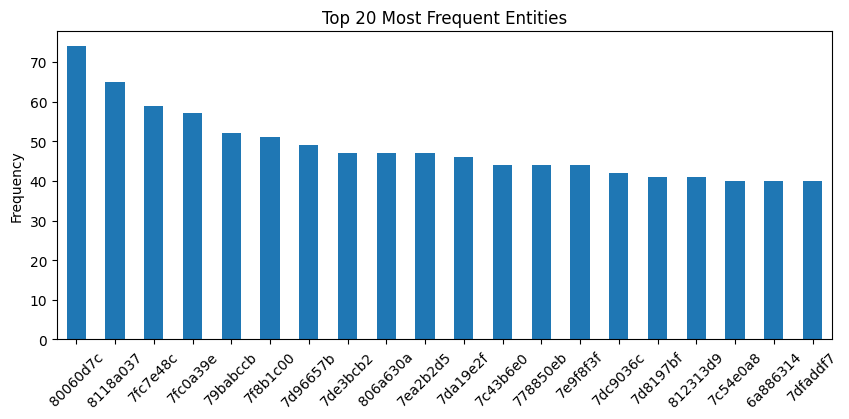

In [ ]:
head_freq = dataframe["head_entity"].value_counts()
tail_freq = dataframe["tail_entity"].value_counts()

print("Top 10 head entities:")
print(head_freq.head(10))

print("\nTop 10 tail entities:")
print(tail_freq.head(10))

entity_freq = (
    dataframe["head_entity"].value_counts() +
    dataframe["tail_entity"].value_counts()
).sort_values(ascending=False)

plt.figure(figsize=(10,4))
entity_freq.head(20).plot(kind="bar")
plt.title("Top 20 Most Frequent Entities")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

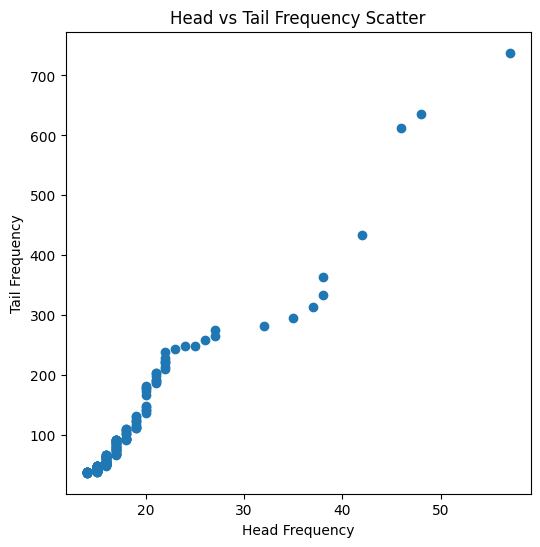

In [ ]:
head_freq = dataframe["head_entity"].value_counts()
tail_freq = dataframe["tail_entity"].value_counts()

plt.figure(figsize=(6,6))
plt.scatter(head_freq.head(200), tail_freq.head(200))
plt.xlabel("Head Frequency")
plt.ylabel("Tail Frequency")
plt.title("Head vs Tail Frequency Scatter")
plt.show()

In [ ]:
print("Split Leakage Checking: ")
if set(["train","valid","test"]).issubset(set(dataframe["split"].unique())):

    train = dataframe[dataframe["split"]=="train"]
    valid = dataframe[dataframe["split"]=="valid"]
    test  = dataframe[dataframe["split"]=="test"]

    train_set = set(zip(train["h_id"], train["r_id"], train["t_id"]))
    valid_set = set(zip(valid["h_id"], valid["r_id"], valid["t_id"]))
    test_set  = set(zip(test["h_id"], test["r_id"], test["t_id"]))

    print("Train ∩ Valid overlap:", len(train_set & valid_set))
    print("Train ∩ Test overlap :", len(train_set & test_set))
    print("Valid ∩ Test overlap :", len(valid_set & test_set))
else:
    print("Split leakage check skipped (missing train/valid/test splits).")

Split Leakage Checking: 
Train ∩ Valid overlap: 0
Train ∩ Test overlap : 0
Valid ∩ Test overlap : 0


Relation Cardinality (1-N, N-1 Patterns): 


,relation,avg_tails_per_head,avg_heads_per_tail
3,paper_in_domain,4.088964,10.731669
2,paper_cite_paper,2.917403,3.296083
1,author_write_paper,1.623963,2.795716
0,author_in_affiliation,1.119456,10.468208
4,paper_in_venue,1.000000,252.350000


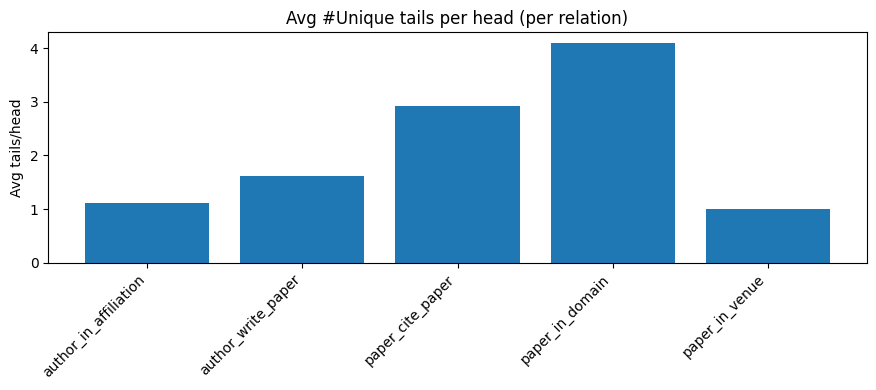

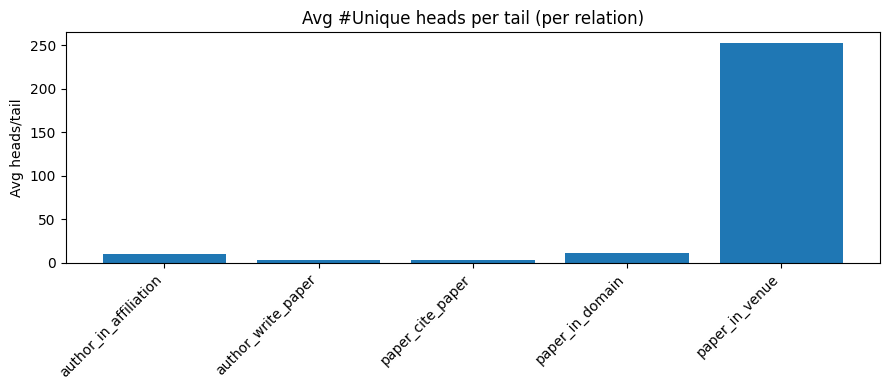

In [ ]:
print("Relation Cardinality (1-N, N-1 Patterns): ")

cardinality= []
for r, group in dataframe.groupby("relation"):
    avg_tails = group.groupby("head_entity")["tail_entity"].nunique().mean()
    avg_heads = group.groupby("tail_entity")["head_entity"].nunique().mean()
    cardinality.append([r, avg_tails, avg_heads])

card = pd.DataFrame(cardinality, columns=["relation", "avg_tails_per_head", "avg_heads_per_tail"])
display(card.sort_values("avg_tails_per_head", ascending=False))

plt.figure(figsize=(9,4))
plt.bar(card["relation"].astype(str), card["avg_tails_per_head"].values)
plt.xticks(rotation=45, ha="right")
plt.title("Avg #Unique tails per head (per relation)")
plt.ylabel("Avg tails/head")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4))
plt.bar(card["relation"].astype(str), card["avg_heads_per_tail"].values)
plt.xticks(rotation=45, ha="right")
plt.title("Avg #Unique heads per tail (per relation)")
plt.ylabel("Avg heads/tail")
plt.tight_layout()
plt.show()

In [ ]:
print("Sparsity: ")
density = num_samples / (num_entities ** 2)
print("Graph density (|T| / |V|^2):", density)

Sparsity: 
Graph density (|T| / |V|^2): 0.0002077096571382817


## EDA with Labeling

In [ ]:
print("Label Distribution:")
print(full_dataset["label"].value_counts())

Label Distribution:
label
1    55607
0    55607
Name: count, dtype: int64


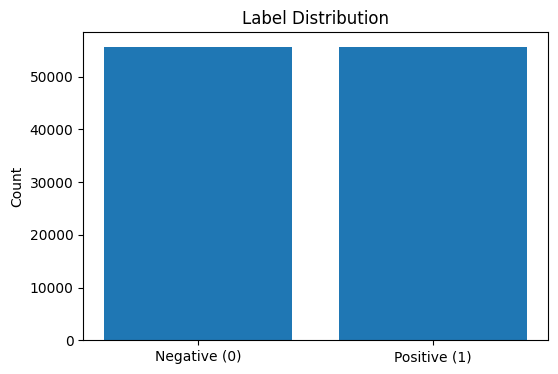

In [ ]:
label_counts = full_dataset["label"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(["Negative (0)", "Positive (1)"], label_counts.values)
plt.title("Label Distribution")
plt.ylabel("Count")
plt.show()

Degree By Label: 


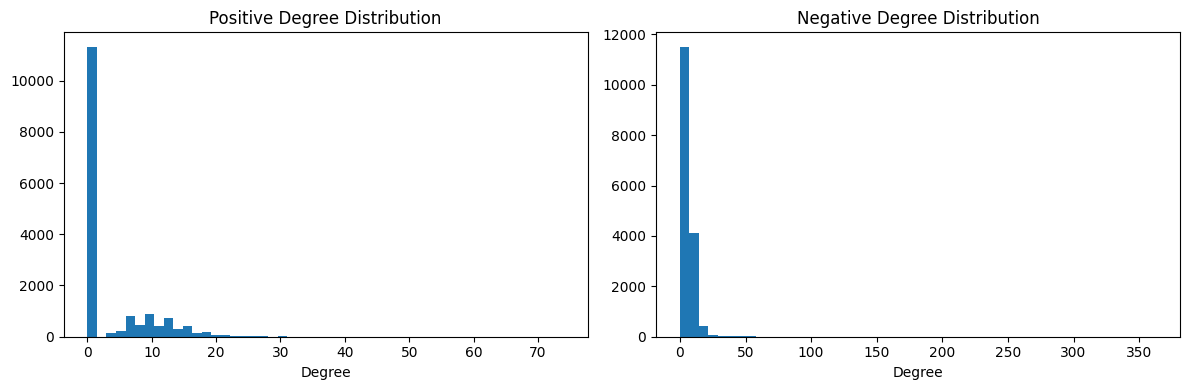

In [ ]:
print("Degree By Label: ")

pos = full_dataset[full_dataset["label"] == 1]
neg = full_dataset[full_dataset["label"] == 0]

# Count how often entities appear in pos vs neg
pos_degree = pos["h_id"].value_counts() + pos["t_id"].value_counts()
neg_degree = neg["h_id"].value_counts() + neg["t_id"].value_counts()

pos_degree = pos_degree.fillna(0)
neg_degree = neg_degree.fillna(0)

fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].hist(pos_degree.values, bins=50)
axes[0].set_title("Positive Degree Distribution")
axes[0].set_xlabel("Degree")

axes[1].hist(neg_degree.values, bins=50)
axes[1].set_title("Negative Degree Distribution")
axes[1].set_xlabel("Degree")

plt.tight_layout()
plt.show()

Relation Distribution By Label


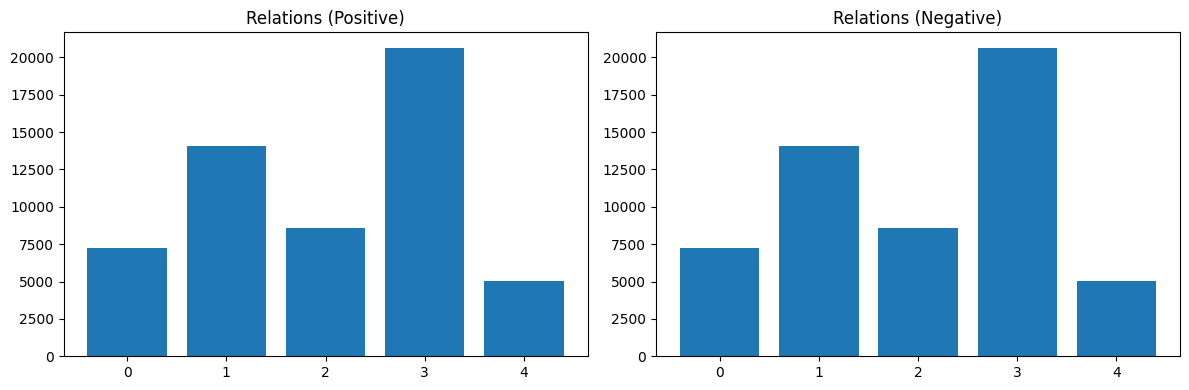

In [ ]:
print("Relation Distribution By Label")

rel_pos = pos["r_id"].value_counts()
rel_neg = neg["r_id"].value_counts()

fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].bar(rel_pos.index, rel_pos.values)
axes[0].set_title("Relations (Positive)")

axes[1].bar(rel_neg.index, rel_neg.values)
axes[1].set_title("Relations (Negative)")

plt.tight_layout()
plt.show()


In [ ]:
print("Negative Sampling Check:")

neg_heads = neg["h_id"].nunique()
neg_tails = neg["t_id"].nunique()

print("Unique heads in negatives:", neg_heads)
print("Unique tails in negatives:", neg_tails)

Negative Sampling Check:
Unique heads in negatives: 15402
Unique tails in negatives: 14548


In [ ]:
print("Basic Correlation:")

corr = full_dataset[["h_id","r_id","t_id","label"]].corr()
print(corr)

Basic Correlation:
           h_id          r_id      t_id         label
h_id   1.000000  6.904562e-03  0.020851  7.684221e-02
r_id   0.006905  1.000000e+00 -0.235395 -8.783119e-15
t_id   0.020851 -2.353945e-01  1.000000 -1.720514e-01
label  0.076842 -8.783119e-15 -0.172051  1.000000e+00


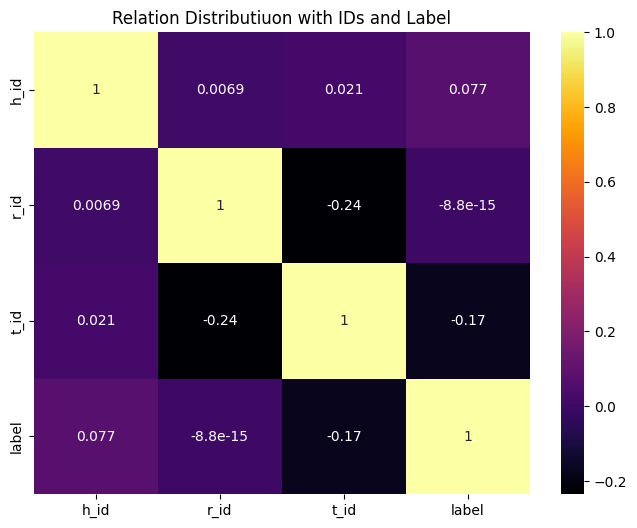

In [ ]:
# heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="inferno")
plt.title("Relation Distributiuon with IDs and Label")
plt.show()

# Feature Engineering

In [ ]:
fe = full_dataset.copy()

In [ ]:
fe["h_id"] = fe["h_id"].astype(np.int32)
fe["r_id"] = fe["r_id"].astype(np.int16)  # relations are small
fe["t_id"] = fe["t_id"].astype(np.int32)
fe["label"] = fe["label"].astype(np.int8)

In [ ]:
h_counts = fe['h_id'].value_counts(sort=False)
t_counts = fe["t_id"].value_counts(sort=False)

In [ ]:
import gc

entity_degree = h_counts.add(t_counts, fill_value=0).astype(np.int32)

fe["h_degree"] = fe["h_id"].map(entity_degree).astype(np.int32)
fe["t_degree"] = fe["t_id"].map(entity_degree).astype(np.int32)

del h_counts, t_counts
gc.collect()

61208

In [ ]:
r_counts = fe["r_id"].value_counts(sort=False).astype(np.int32)
fe["r_freq"] = fe["r_id"].map(r_counts).astype(np.int32)

del r_counts
gc.collect()

0

In [ ]:
hr_tbl = (
    fe.groupby(["h_id","r_id"], sort=False)
      .size()
      .reset_index(name="hr_freq")
)
hr_tbl["hr_freq"] = hr_tbl["hr_freq"].astype(np.int32)
fe = fe.merge(hr_tbl, on=["h_id","r_id"], how="left")

del hr_tbl
gc.collect()

0

In [ ]:
tr_tbl = (
    fe.groupby(["t_id","r_id"], sort=False)
      .size()
      .reset_index(name="tr_freq")
)
tr_tbl["tr_freq"] = tr_tbl["tr_freq"].astype(np.int32)
fe = fe.merge(tr_tbl, on=["t_id","r_id"], how="left")

del tr_tbl
gc.collect()

0

In [ ]:
fe["deg_sum"] = (fe["h_degree"] + fe["t_degree"]).astype(np.int32)
fe["deg_diff"] = (fe["h_degree"] - fe["t_degree"]).abs().astype(np.int32)
fe["deg_product"] = (fe["h_degree"].astype(np.int64) * fe["t_degree"].astype(np.int64)).astype(np.int64)

fe["hr_strength"] = (fe["hr_freq"] / (fe["h_degree"] + 1.0)).astype(np.float32)
fe["tr_strength"] = (fe["tr_freq"] / (fe["t_degree"] + 1.0)).astype(np.float32)
fe["r_prob"] = (fe["r_freq"] / float(fe["r_freq"].sum())).astype(np.float32)

In [ ]:
for c in ["h_degree","t_degree","r_freq","hr_freq","tr_freq","deg_sum","deg_product"]:
    fe[f"log_{c}"] = np.log1p(fe[c].astype(np.float32))

In [ ]:
fe.replace([np.inf, -np.inf], np.nan, inplace=True)
fe.fillna(0, inplace=True)

feature_cols = [
    "h_degree","t_degree","r_freq","hr_freq","tr_freq",
    "deg_sum","deg_diff","deg_product",
    "hr_strength","tr_strength","r_prob",
    "log_h_degree","log_t_degree","log_r_freq",
    "log_hr_freq","log_tr_freq","log_deg_sum","log_deg_product"
]

print("Done. fe shape:", fe.shape)
print("Memory (MB):", fe.memory_usage(deep=True).sum()/1e6)
fe[feature_cols + ["label"]].head()

Done. fe shape: (111214, 22)
Memory (MB): 9.67575


,h_degree,t_degree,r_freq,hr_freq,tr_freq,deg_sum,deg_diff,deg_product,hr_strength,tr_strength,r_prob,log_h_degree,log_t_degree,log_r_freq,log_hr_freq,log_tr_freq,log_deg_sum,log_deg_product,label
0,6,5,14488,2,1,11,1,30,0.285714,0.166667,0.000005,1.945910,1.791759,9.581145,1.098612,0.693147,2.484907,3.433987,1
1,4,13,14488,1,11,17,9,52,0.200000,0.785714,0.000005,1.609438,2.639057,9.581145,0.693147,2.484907,2.890372,3.970292,1
2,21,20,28192,13,5,41,1,420,0.590909,0.238095,0.000009,3.091043,3.044523,10.246829,2.639057,1.791759,3.737670,6.042633,1
3,4,14,28192,1,5,18,10,56,0.200000,0.333333,0.000009,1.609438,2.708050,10.246829,0.693147,1.791759,2.944439,4.043051,1
4,36,34,17166,16,10,70,2,1224,0.432432,0.285714,0.000006,3.610918,3.555348,9.750744,2.833213,2.397895,4.262680,7.110696,1


In [ ]:
entity_degree = (h_counts.add(t_counts, fill_value=0)).astype(np.int64)

fe["h_degree"] = fe["h_id"].map(entity_degree).fillna(0).astype(np.int64)
fe["t_degree"] = fe["t_id"].map(entity_degree).fillna(0).astype(np.int64)

NameError: name 'h_counts' is not defined

In [ ]:
rel_freq = fe["r_id"].value_counts()
fe["r_freq"] = fe["r_id"].map(rel_freq).fillna(0).astype(int)

In [ ]:
hr_freq = fe.groupby(["h_id", "r_id"]).size().astype(np.int64)
fe["hr_freq"] = list(zip(fe["h_id"], fe["r_id"]))
fe["hr_freq"] = fe["hr_freq"].map(hr_freq).fillna(0).astype(np.int64)

tr_freq = fe.groupby(["t_id", "r_id"]).size().astype(np.int64)
fe["tr_freq"] = list(zip(fe["t_id"], fe["r_id"]))
fe["tr_freq"] = fe["tr_freq"].map(tr_freq).fillna(0).astype(np.int64)


In [ ]:
ht_freq = fe.groupby(["h_id", "t_id"]).size().astype(np.int64)
fe["ht_freq"] = list(zip(fe["h_id"], fe["t_id"]))
fe["ht_freq"] = fe["ht_freq"].map(ht_freq).fillna(0).astype(np.int64)

In [ ]:
fe["deg_sum"] = (fe["h_degree"] + fe["t_degree"]).astype(np.int64)
fe["deg_diff"] = (fe["h_degree"] - fe["t_degree"]).abs().astype(np.int64)
fe["deg_product"] = (fe["h_degree"] * fe["t_degree"]).astype(np.int64)

In [ ]:
fe["hr_strength"] = fe["hr_freq"] / (fe["h_degree"] + 1.0)
fe["tr_strength"] = fe["tr_freq"] / (fe["t_degree"] + 1.0)

fe["r_prob"] = fe["r_freq"] / float(fe["r_freq"].sum())

In [ ]:
log_cols = ["h_degree","t_degree","r_freq","hr_freq","tr_freq","ht_freq","deg_sum","deg_product"]
for c in log_cols:
    fe[f"log_{c}"] = np.log1p(fe[c].astype(float))

# Clean any inf/nan from divisions (should be rare)
fe.replace([np.inf, -np.inf], np.nan, inplace=True)
fe.fillna(0, inplace=True)

In [ ]:
feature_cols = [
    "h_degree","t_degree","r_freq",
    "hr_freq","tr_freq","ht_freq",
    "deg_sum","deg_diff","deg_product",
    "hr_strength","tr_strength","r_prob",
    "log_h_degree","log_t_degree","log_r_freq",
    "log_hr_freq","log_tr_freq","log_ht_freq",
    "log_deg_sum","log_deg_product"
]

print("df_fe shape:", fe.shape)
print("num features:", len(feature_cols))
fe[feature_cols + (["label"] if "label" in fe.columns else [])].head()

df_fe shape: (111214, 24)
num features: 20


,h_degree,t_degree,r_freq,hr_freq,tr_freq,ht_freq,deg_sum,deg_diff,deg_product,hr_strength,...,r_prob,log_h_degree,log_t_degree,log_r_freq,log_hr_freq,log_tr_freq,log_ht_freq,log_deg_sum,log_deg_product,label
0,6,5,14488,2,1,1,11,1,30,0.285714,...,0.000005,1.945910,1.791759,9.581145,1.098612,0.693147,0.693147,2.484907,3.433987,1
1,4,13,14488,1,11,1,17,9,52,0.200000,...,0.000005,1.609438,2.639057,9.581145,0.693147,2.484907,0.693147,2.890372,3.970292,1
2,21,20,28192,13,5,1,41,1,420,0.590909,...,0.000009,3.091042,3.044522,10.246829,2.639057,1.791759,0.693147,3.737670,6.042633,1
3,4,14,28192,1,5,1,18,10,56,0.200000,...,0.000009,1.609438,2.708050,10.246829,0.693147,1.791759,0.693147,2.944439,4.043051,1
4,36,34,17166,16,10,1,70,2,1224,0.432432,...,0.000006,3.610918,3.555348,9.750744,2.833213,2.397895,0.693147,4.262680,7.110696,1


In [ ]:
train_df, test_df = train_test_split(
    fe,
    test_size=0.2,
    random_state=42,
    stratify=full_dataset["label"]
)

train_df, valid_df = train_test_split(
    train_df,
    test_size=0.1,            # 10% of train becomes valid (~72/8/20 overall)
    random_state=42,
    stratify=train_df["label"]
)

print("Train Set:", len(train_df), "Valid Set:", len(valid_df), "Test Set:", len(test_df))
print("Train label balance:\n", train_df["label"].value_counts())

Train Set: 80073 Valid Set: 8898 Test Set: 22243
Train label balance:
 label
1    40037
0    40036
Name: count, dtype: int64


In [ ]:
train_df, test_df = train_test_split(fe, test_size=0.2, random_state=42, stratify=fe["label"])
train_df, valid_df = train_test_split(train_df, test_size=0.1, random_state=42, stratify=train_df["label"])
print("Train Set:", len(train_df), "Valid Set:", len(valid_df), "Test Set:", len(test_df))
print("Train label balance:\n", train_df["label"].value_counts())

Train Set: 80073 Valid Set: 8898 Test Set: 22243
Train label balance:
 label
1    40037
0    40036
Name: count, dtype: int64


In [ ]:
missing = [c for c in feature_cols if c not in fe.columns]
print("Missing feature columns:", missing)

Missing feature columns: []


# Model Training

In [ ]:
X_train = train_df[feature_cols].values
y_train = train_df["label"].values

X_valid = valid_df[feature_cols].values
y_valid = valid_df["label"].values

X_test = test_df[feature_cols].values
y_test = test_df["label"].values

# Scale features (important for Logistic + NN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

## Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=3000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Model: ")
print(classification_report(y_test, lr_pred))

Logistic Regression Model: 
              precision    recall  f1-score   support

           0       0.74      0.74      0.74     11122
           1       0.74      0.75      0.74     11121

    accuracy                           0.74     22243
   macro avg       0.74      0.74      0.74     22243
weighted avg       0.74      0.74      0.74     22243



In [ ]:
acc_lr = accuracy_score(y_test, lr_pred)
print("Logistic Regression Test Accuracy:", acc_lr)

Logistic Regression Test Accuracy: 0.7425257384345637


In [ ]:
auc_lr = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])
print("LR AUC:", auc_lr)

LR AUC: 0.8171418648515931


In [ ]:
valid_pred_lr = lr.predict(X_valid)
acc_valid_lr = accuracy_score(y_valid, valid_pred_lr)

test_pred_lr = lr.predict(X_test)
acc_test_lr = accuracy_score(y_test, test_pred_lr)

print("Train Accuracy:", acc_lr)
print("Valid Accuracy:", acc_valid_lr)
print("Test Accuracy :", acc_test_lr)
print("Overfitting Gap (Train - Test):", acc_lr - acc_test_lr)

Train Accuracy: 0.7425257384345637
Valid Accuracy: 0.7429759496516071
Test Accuracy : 0.7425257384345637
Overfitting Gap (Train - Test): 0.0


## Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=200,random_state=42,n_jobs=-1)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Model: ")
print(classification_report(y_test, rf_pred))

Random Forest Model: 
              precision    recall  f1-score   support

           0       0.82      0.74      0.78     11122
           1       0.76      0.83      0.80     11121

    accuracy                           0.79     22243
   macro avg       0.79      0.79      0.79     22243
weighted avg       0.79      0.79      0.79     22243



In [ ]:
acc_rf = accuracy_score(y_test, rf_pred)
print("Random Forest Test Accuracy:", acc_rf)

Random Forest Test Accuracy: 0.7865845434518725


In [ ]:
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
print("RF AUC:", auc_rf)

RF AUC: 0.857966174535521


In [ ]:
valid_pred_rf = rf.predict(X_valid)
acc_valid_rf = accuracy_score(y_valid, valid_pred_rf)

test_pred_rf = rf.predict(X_test)
acc_test_rf = accuracy_score(y_test, test_pred_rf)

print("Train Accuracy:", acc_rf)
print("Valid Accuracy:", acc_valid_rf)
print("Test Accuracy :", acc_test_rf)
print("Overfitting Gap (Train - Test):", acc_rf - acc_test_rf)

Train Accuracy: 0.7865845434518725
Valid Accuracy: 0.7877051022701731
Test Accuracy : 0.7865845434518725
Overfitting Gap (Train - Test): 0.0


## Neural Network

In [ ]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model_train = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=20,
    batch_size=256
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7575 - loss: 0.4995 - val_accuracy: 0.7911 - val_loss: 0.4587
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7942 - loss: 0.4456 - val_accuracy: 0.7968 - val_loss: 0.4372
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8022 - loss: 0.4308 - val_accuracy: 0.8042 - val_loss: 0.4260
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8056 - loss: 0.4222 - val_accuracy: 0.8058 - val_loss: 0.4205
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8072 - loss: 0.4175 - val_accuracy: 0.8089 - val_loss: 0.4160
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8089 - loss: 0.4125 - val_accuracy: 0.8106 - val_loss: 0.4152
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8112 - loss: 0.4099 - val_accuracy: 0.8088 - val_loss: 0.4103
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8126 - loss: 0.4072 - val_accuracy: 0.

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

696/696 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8116 - loss: 0.4051
Test Accuracy: 0.811626136302948


In [ ]:
y_pred = model.predict(X_test)
auc = roc_auc_score(y_test, y_pred)
print("Test AUC:", auc)

696/696 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Test AUC: 0.8847844906434641


In [ ]:
# Step 1: get probabilities
y_pred_prob = model.predict(X_test)

# Step 2: convert to 0/1 using threshold 0.5
y_pred = (y_pred_prob > 0.5).astype(int)

# Step 3: print report
print(classification_report(y_test, y_pred))

696/696 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           0       0.89      0.71      0.79     11122
           1       0.76      0.92      0.83     11121

    accuracy                           0.81     22243
   macro avg       0.83      0.81      0.81     22243
weighted avg       0.83      0.81      0.81     22243



In [ ]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
valid_loss, valid_acc = model.evaluate(X_valid, y_valid, verbose=0)
test_loss,  test_acc  = model.evaluate(X_test,  y_test,  verbose=0)

print("Train Accuracy:", train_acc)
print("Valid Accuracy:", valid_acc)
print("Test Accuracy :", test_acc)
print("Overfitting Gap (Train - Test):", train_acc - test_acc)

Train Accuracy: 0.8172792196273804
Valid Accuracy: 0.8144527077674866
Test Accuracy : 0.811626136302948
Overfitting Gap (Train - Test): 0.005653083324432373


## TransE

In [ ]:
ebd = dataframe.copy()
num_entities = int(max(ebd["h_id"].max(), ebd["t_id"].max()) + 1)
num_relations = int(ebd["r_id"].max() + 1)

print("Entities:", num_entities, "Relations:", num_relations, "Triples:", len(ebd))
print(ebd[["h_id","r_id","t_id","split"]].head())

Entities: 16362 Relations: 5 Triples: 55607
    h_id  r_id   t_id  split
0   3877     0   1915  train
1   1603     0    229  train
2  12953     1  10004  train
3   7398     1   5957  train
4  11891     2   4979  train


In [ ]:
train_ebd = ebd[ebd["split"]=="train"][["h_id","r_id","t_id"]].copy()
valid_ebd = ebd[ebd["split"]=="valid"][["h_id","r_id","t_id"]].copy()
test_ebd  = ebd[ebd["split"]=="test"][["h_id","r_id","t_id"]].copy()

print("Train:", len(train_ebd), "Valid:", len(valid_ebd), "Test:", len(test_ebd))

Train: 48213 Valid: 3670 Test: 3724


In [ ]:
all_true = dataframe[["h_id","r_id","t_id"]].astype(int).values
all_true_set = set(map(tuple, all_true))

# For filtering, we also want per (h,r) -> tails and per (r,t) -> heads
hr2t = {}
rt2h = {}

for h,r,t in all_true:
    hr2t.setdefault((h,r), set()).add(t)
    rt2h.setdefault((r,t), set()).add(h)

print("All true triples:", len(all_true))

All true triples: 55607


In [ ]:
import numpy as np
import torch

@torch.no_grad()
def filtered_metrics_chunked(model, eval_df, num_entities, hr2t, rt2h,
                             hits=(1,3,10), batch_size=32, cand_chunk=1024):
    """
    RAM-safe filtered ranking for TransE/DistMult style models with:
      model.ent (nn.Embedding), model.rel (nn.Embedding)
      model.score(h, r, t) returning [batch] scores (higher is better)
    """
    model.eval()
    ranks = []

    triples = eval_df[["h_id","r_id","t_id"]].astype(int).values
    n = len(triples)

    all_entities = torch.arange(num_entities, device=device, dtype=torch.long)

    for start in range(0, n, batch_size):
        chunk = triples[start:start+batch_size]
        h = torch.tensor(chunk[:,0], device=device, dtype=torch.long)
        r = torch.tensor(chunk[:,1], device=device, dtype=torch.long)
        t = torch.tensor(chunk[:,2], device=device, dtype=torch.long)

        # gold scores
        gold_tail_score = model.score(h, r, t)  # [B]
        gold_head_score = model.score(h, r, t)  # same for head ranking, reuse

        # ---------- Tail prediction ranks ----------
        better_count = torch.zeros(len(h), device=device, dtype=torch.long)

        for cstart in range(0, num_entities, cand_chunk):
            cend = min(num_entities, cstart + cand_chunk)
            cand_t = all_entities[cstart:cend]  # [C]

            # compute scores for each (h,r) against candidate tails cand_t
            # chunked broadcast: [B,1,D] vs [1,C,D] -> [B,C,D] (manageable)
            he = model.ent(h)                      # [B,D]
            re = model.rel(r)                      # [B,D]
            te = model.ent(cand_t)                 # [C,D]

            if model.__class__.__name__.lower().startswith("transe"):
                hr = he + re                       # [B,D]
                scores = -(hr[:,None,:] - te[None,:,:]).abs().sum(dim=2)  # [B,C]
            else:
                # DistMult
                scores = (he[:,None,:] * re[:,None,:] * te[None,:,:]).sum(dim=2)  # [B,C]

            # apply filtered masking per example for this candidate chunk
            for i in range(len(h)):
                key = (int(h[i].item()), int(r[i].item()))
                if key in hr2t:
                    filt = hr2t[key]
                    gold = int(t[i].item())
                    # mask only entities that are inside this candidate slice
                    for bad_t in filt:
                        if bad_t != gold and cstart <= bad_t < cend:
                            scores[i, bad_t - cstart] = -1e9

            # count candidates with score > gold
            better_count += (scores > gold_tail_score.view(-1,1)).sum(dim=1)

        rank_tail = better_count + 1
        ranks.append(rank_tail.detach().cpu())

        # ---------- Head prediction ranks ----------
        better_count = torch.zeros(len(h), device=device, dtype=torch.long)

        for cstart in range(0, num_entities, cand_chunk):
            cend = min(num_entities, cstart + cand_chunk)
            cand_h = all_entities[cstart:cend]  # [C]

            # score candidates heads for each (r,t)
            he = model.ent(cand_h)               # [C,D]
            re = model.rel(r)                    # [B,D]
            te = model.ent(t)                    # [B,D]

            if model.__class__.__name__.lower().startswith("transe"):
                rt = re - te                     # [B,D] since score = -||h + r - t||
                # want scores for h candidates: -||h + r - t|| = -||h - (t - r)||, equivalent:
                target = te - re                 # [B,D]
                scores = -(he[None,:,:] - target[:,None,:]).abs().sum(dim=2)  # [B,C]
            else:
                # DistMult score(h,r,t) = <h, r, t>
                scores = (he[None,:,:] * re[:,None,:] * te[:,None,:]).sum(dim=2)  # [B,C]

            # filtered masking
            for i in range(len(t)):
                key = (int(r[i].item()), int(t[i].item()))
                if key in rt2h:
                    filt = rt2h[key]
                    gold = int(h[i].item())
                    for bad_h in filt:
                        if bad_h != gold and cstart <= bad_h < cend:
                            scores[i, bad_h - cstart] = -1e9

            better_count += (scores > gold_head_score.view(-1,1)).sum(dim=1)

        rank_head = better_count + 1
        ranks.append(rank_head.detach().cpu())

    ranks = torch.cat(ranks).numpy().astype(np.int64)

    mrr = float(np.mean(1.0 / ranks))
    out = {"MRR": mrr}
    for k in hits:
        out[f"Hits@{k}"] = float(np.mean(ranks <= k))
    return out

In [ ]:
class TransE(nn.Module):
    def __init__(self, n_ent, n_rel, dim=100, margin=1.0):
        super().__init__()
        self.ent = nn.Embedding(n_ent, dim)
        self.rel = nn.Embedding(n_rel, dim)
        self.margin = margin
        nn.init.xavier_uniform_(self.ent.weight)
        nn.init.xavier_uniform_(self.rel.weight)

    def score(self, h, r, t):
        # higher is better, so use negative distance
        he = self.ent(h)
        re = self.rel(r)
        te = self.ent(t)
        return -(he + re - te).abs().sum(dim=1)

class DistMult(nn.Module):
    def __init__(self, n_ent, n_rel, dim=100):
        super().__init__()
        self.ent = nn.Embedding(n_ent, dim)
        self.rel = nn.Embedding(n_rel, dim)
        nn.init.xavier_uniform_(self.ent.weight)
        nn.init.xavier_uniform_(self.rel.weight)

    def score(self, h, r, t):
        he = self.ent(h)
        re = self.rel(r)
        te = self.ent(t)
        return (he * re * te).sum(dim=1)

class ComplEx(nn.Module):
    def __init__(self, n_ent, n_rel, dim=100):
        super().__init__()
        # use dim for real, dim for imag
        self.ent_re = nn.Embedding(n_ent, dim)
        self.ent_im = nn.Embedding(n_ent, dim)
        self.rel_re = nn.Embedding(n_rel, dim)
        self.rel_im = nn.Embedding(n_rel, dim)
        for emb in [self.ent_re, self.ent_im, self.rel_re, self.rel_im]:
            nn.init.xavier_uniform_(emb.weight)

    def score(self, h, r, t):
        hr = self.ent_re(h); hi = self.ent_im(h)
        rr = self.rel_re(r); ri = self.rel_im(r)
        tr = self.ent_re(t); ti = self.ent_im(t)

        # Re(<h,r,conj(t)>)
        return (hr*rr*tr + hi*rr*ti + hr*ri*ti - hi*ri*tr).sum(dim=1)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# choose model
MODEL_NAME = "transe"   # "transe" or "distmult" or "complex"
DIM = 100
BATCH = 1024
EPOCHS = 20
LR = 1e-3
MARGIN = 1.0

if MODEL_NAME == "transe":
    model = TransE(num_entities, num_relations, dim=DIM, margin=MARGIN)
elif MODEL_NAME == "distmult":
    model = DistMult(num_entities, num_relations, dim=DIM)
elif MODEL_NAME == "complex":
    model = ComplEx(num_entities, num_relations, dim=DIM)
else:
    raise ValueError("Unknown MODEL_NAME")

model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MarginRankingLoss(margin=MARGIN)

train_triples = torch.tensor(train_df.values, dtype=torch.long)
train_loader = DataLoader(TensorDataset(train_triples), batch_size=BATCH, shuffle=True, drop_last=True)

print("Training", MODEL_NAME, "on", device)

Training transe on cpu


In [ ]:
for epoch in range(1, EPOCHS+1):
    model.train()
    total_loss = 0.0

    for (batch,) in train_loader:
        batch = batch.to(device)
        h = batch[:,0]
        r = batch[:,1]
        t = batch[:,2]

        # negative sampling: corrupt head OR tail
        corrupt_head = (torch.rand(len(batch), device=device) < 0.5)
        rand_ents = torch.randint(0, num_entities, (len(batch),), device=device)

        h_neg = torch.where(corrupt_head, rand_ents, h)
        t_neg = torch.where(corrupt_head, t, rand_ents)

        pos_scores = model.score(h, r, t)
        neg_scores = model.score(h_neg, r, t_neg)

        # MarginRankingLoss expects: loss(pos, neg, target=+1) with pos > neg desired
        target = torch.ones_like(pos_scores)
        loss = loss_fn(pos_scores, neg_scores, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch:02d} | loss={total_loss/len(train_loader):.4f}")

Epoch 01 | loss=0.7695
Epoch 02 | loss=0.5618
Epoch 03 | loss=0.4905
Epoch 04 | loss=0.4549
Epoch 05 | loss=0.4292
Epoch 06 | loss=0.4098
Epoch 07 | loss=0.3861
Epoch 08 | loss=0.3758
Epoch 09 | loss=0.3567
Epoch 10 | loss=0.3398
Epoch 11 | loss=0.3212
Epoch 12 | loss=0.3099
Epoch 13 | loss=0.2957
Epoch 14 | loss=0.2808
Epoch 15 | loss=0.2672
Epoch 16 | loss=0.2532
Epoch 17 | loss=0.2387
Epoch 18 | loss=0.2239
Epoch 19 | loss=0.2121
Epoch 20 | loss=0.2053


In [ ]:
valid_metrics = filtered_metrics_chunked(model, valid_df, num_entities, hr2t, rt2h,
                                        batch_size=16, cand_chunk=512)
test_metrics  = filtered_metrics_chunked(model, test_df, num_entities, hr2t, rt2h,
                                        batch_size=16, cand_chunk=512)

print("Valid:", valid_metrics)
print("Test :", test_metrics)

KeyboardInterrupt: 

In [ ]:
print(dataframe.columns)
print(dataframe['split'].value_counts())

Index(['head_entity', 'relation', 'tail_entity', 'split', 'h_id', 'r_id',
       't_id', 'label'],
      dtype='object')
split
train    48213
test      3724
valid     3670
Name: count, dtype: int64


In [ ]:
@torch.no_grad()
def filtered_ranking_metrics(dataframe, hits=(1,3,10), batch_eval=256):
    model.eval()

    ranks = []

    eval_triples = dataframe[["h_id","r_id","t_id"]].values.astype(int)
    n = len(eval_triples)

    for start in range(0, n, batch_eval):
        chunk = eval_triples[start:start+batch_eval]
        h = torch.tensor(chunk[:,0], dtype=torch.long, device=device)
        r = torch.tensor(chunk[:,1], dtype=torch.long, device=device)
        t = torch.tensor(chunk[:,2], dtype=torch.long, device=device)

        # ---- Tail prediction ranks ----
        # score all candidates t' for each (h,r)
        all_t = torch.arange(num_entities, device=device).view(1, -1).repeat(len(h), 1)
        h_rep = h.view(-1,1).repeat(1, num_entities).reshape(-1)
        r_rep = r.view(-1,1).repeat(1, num_entities).reshape(-1)
        t_cand = all_t.reshape(-1)

        scores = model.score(h_rep, r_rep, t_cand).view(len(h), num_entities)

        # filtered: remove other true tails for (h,r), except the gold t
        for i in range(len(h)):
            key = (int(h[i].item()), int(r[i].item()))
            if key in hr2t:
                filt = hr2t[key].copy()
                gold = int(t[i].item())
                if gold in filt:
                    filt.remove(gold)
                if len(filt) > 0:
                    scores[i, list(filt)] = -1e9

        gold_scores = scores[torch.arange(len(h), device=device), t]
        # rank = 1 + number of candidates with score > gold_score
        rank_t = (scores > gold_scores.view(-1,1)).sum(dim=1) + 1
        ranks.append(rank_t.detach().cpu())

        # ---- Head prediction ranks ----
        all_h = torch.arange(num_entities, device=device).view(1, -1).repeat(len(t), 1)
        t_rep = t.view(-1,1).repeat(1, num_entities).reshape(-1)
        r_rep2 = r.view(-1,1).repeat(1, num_entities).reshape(-1)
        h_cand = all_h.reshape(-1)

        scores_h = model.score(h_cand, r_rep2, t_rep).view(len(t), num_entities)

        # filtered: remove other true heads for (r,t), except the gold h
        for i in range(len(t)):
            key = (int(r[i].item()), int(t[i].item()))
            if key in rt2h:
                filt = rt2h[key].copy()
                gold = int(h[i].item())
                if gold in filt:
                    filt.remove(gold)
                if len(filt) > 0:
                    scores_h[i, list(filt)] = -1e9

        gold_scores_h = scores_h[torch.arange(len(t), device=device), h]
        rank_h = (scores_h > gold_scores_h.view(-1,1)).sum(dim=1) + 1
        ranks.append(rank_h.detach().cpu())

    ranks = torch.cat(ranks).numpy().astype(np.int64)

    mrr = np.mean(1.0 / ranks)
    metrics = {"MRR": float(mrr)}
    for k in hits:
        metrics[f"Hits@{k}"] = float(np.mean(ranks <= k))
    return metrics

print("Valid metrics:", filtered_ranking_metrics(valid_df))
print("Test metrics :", filtered_ranking_metrics(test_df))

## DistMult

In [ ]:
DIM = 100

model = DistMult(num_entities, num_relations, dim=DIM).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MarginRankingLoss(margin=1.0)

print("Training DistMult...")

Training DistMult...


In [ ]:
EPOCHS = 20
BATCH = 1024

train_triples = torch.tensor(train_df[["h_id","r_id","t_id"]].values, dtype=torch.long)
train_loader = DataLoader(TensorDataset(train_triples), batch_size=BATCH, shuffle=True, drop_last=True)

for epoch in range(1, EPOCHS+1):
    model.train()
    total_loss = 0

    for (batch,) in train_loader:
        batch = batch.to(device)
        h = batch[:,0]
        r = batch[:,1]
        t = batch[:,2]

        # Negative sampling
        corrupt_head = (torch.rand(len(batch), device=device) < 0.5)
        rand_ents = torch.randint(0, num_entities, (len(batch),), device=device)

        h_neg = torch.where(corrupt_head, rand_ents, h)
        t_neg = torch.where(corrupt_head, t, rand_ents)

        pos_scores = model.score(h, r, t)
        neg_scores = model.score(h_neg, r, t_neg)

        target = torch.ones_like(pos_scores)
        loss = loss_fn(pos_scores, neg_scores, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch:02d} | Loss: {total_loss/len(train_loader):.4f}")


Epoch 01 | Loss: 1.0000
Epoch 02 | Loss: 0.9989
Epoch 03 | Loss: 0.9914
Epoch 04 | Loss: 0.9563
Epoch 05 | Loss: 0.8567
Epoch 06 | Loss: 0.6822
Epoch 07 | Loss: 0.5023
Epoch 08 | Loss: 0.3413
Epoch 09 | Loss: 0.2090
Epoch 10 | Loss: 0.1199
Epoch 11 | Loss: 0.0714
Epoch 12 | Loss: 0.0450
Epoch 13 | Loss: 0.0317
Epoch 14 | Loss: 0.0241
Epoch 15 | Loss: 0.0195
Epoch 16 | Loss: 0.0168
Epoch 17 | Loss: 0.0146
Epoch 18 | Loss: 0.0138
Epoch 19 | Loss: 0.0129
Epoch 20 | Loss: 0.0111


In [ ]:
valid_metrics = filtered_metrics_chunked(
    model, valid_df, num_entities, hr2t, rt2h,
    batch_size=16, cand_chunk=512
)

test_metrics = filtered_metrics_chunked(
    model, test_df, num_entities, hr2t, rt2h,
    batch_size=16, cand_chunk=512
)

print("DistMult Valid:", valid_metrics)
print("DistMult Test :", test_metrics)

# Simple Baselines for Comparison

In [ ]:
results_table = {}

## Random Classifier Baseline

In [ ]:
random_clf = DummyClassifier(strategy="uniform", random_state=42)
random_clf.fit(X_train, y_train)
y_pred_random = random_clf.predict(X_test)
y_prob_random = random_clf.predict_proba(X_test)[:,1]

acc_random = accuracy_score(y_test, y_pred_random)
f1_random  = f1_score(y_test, y_pred_random, average='macro')
auc_random = roc_auc_score(y_test, y_prob_random)

print(f"\n[1] Random Baseline")
print(f"    Accuracy : {acc_random:.4f}")
print(f"    F1 (macro): {f1_random:.4f}")
print(f"    ROC-AUC  : {auc_random:.4f}")

results_table['Random Baseline'] = dict(Accuracy=acc_random, F1=f1_random, AUC=auc_random)



[1] Random Baseline
    Accuracy : 0.5015
    F1 (macro): 0.5015
    ROC-AUC  : 0.5000


## Majority Class Baseline

In [ ]:
majority_clf = DummyClassifier(strategy="most_frequent", random_state=42)
majority_clf.fit(X_train, y_train)
y_pred_majority = majority_clf.predict(X_test)

acc_majority = accuracy_score(y_test, y_pred_majority)
f1_majority  = f1_score(y_test, y_pred_majority, average='macro', zero_division=0)

print(f"\n[2] Majority Class Baseline")
print(f"    Accuracy : {acc_majority:.4f}")
print(f"    F1 (macro): {f1_majority:.4f}")
print(f"    ROC-AUC  : N/A (single class prediction)")

results_table['Majority Class'] = dict(Accuracy=acc_majority, F1=f1_majority, AUC=float('nan'))



[2] Majority Class Baseline
    Accuracy : 0.5000
    F1 (macro): 0.3333
    ROC-AUC  : N/A (single class prediction)


## Degree Heuristic Baseline

In [ ]:
deg_idx_h = feature_cols.index("h_degree")
deg_idx_t = feature_cols.index("t_degree")

# Use raw (unscaled) degree from test_df
raw_h_deg = test_df["h_degree"].values
raw_t_deg = test_df["t_degree"].values
deg_scores = (raw_h_deg + raw_t_deg).astype(float)
threshold = np.median(deg_scores)
y_pred_deg = (deg_scores >= threshold).astype(int)
y_prob_deg = (deg_scores - deg_scores.min()) / (deg_scores.max() - deg_scores.min() + 1e-9)

acc_deg = accuracy_score(y_test, y_pred_deg)
f1_deg  = f1_score(y_test, y_pred_deg, average='macro')
auc_deg = roc_auc_score(y_test, y_prob_deg)

print(f"\n[3] Degree Heuristic Baseline")
print(f"    Accuracy : {acc_deg:.4f}")
print(f"    F1 (macro): {f1_deg:.4f}")
print(f"    ROC-AUC  : {auc_deg:.4f}")

results_table['Degree Heuristic'] = dict(Accuracy=acc_deg, F1=f1_deg, AUC=auc_deg)


[3] Degree Heuristic Baseline
    Accuracy : 0.6094
    F1 (macro): 0.6093
    ROC-AUC  : 0.6422


# Hyperparameter Tuning

## Tuning Logistic Regression

In [ ]:
t0 = time.time()

lr_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'max_iter': [3000]
}

lr_gs = GridSearchCV(
    LogisticRegression(),
    lr_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
lr_gs.fit(X_train, y_train)

print("\n Tuning Logistic Regression Results:")
print(f"    Best params : {lr_gs.best_params_}")
print(f"    Best CV AUC : {lr_gs.best_score_:.4f}  ({time.time()-t0:.1f}s)")

lr_best = lr_gs.best_estimator_


 Tuning Logistic Regression Results:
    Best params : {'C': 10, 'max_iter': 3000, 'penalty': 'l2', 'solver': 'lbfgs'}
    Best CV AUC : 0.8201  (26.2s)


## Tuning Random Forest Classifier

In [ ]:
t0 = time.time()

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_leaf': [1, 5],
}

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=2,          # 3-fold to keep runtime manageable
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
rf_gs.fit(X_train, y_train)
print("\n Tuning Random Forest Classifier Results:")
print(f"    Best params : {rf_gs.best_params_}")
print(f"    Best CV AUC : {rf_gs.best_score_:.4f}  ({time.time()-t0:.1f}s)")

rf_best = rf_gs.best_estimator_



 Tuning Random Forest Classifier Results:
    Best params : {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}
    Best CV AUC : 0.8880  (206.1s)


## Tuning Neural Networks

In [ ]:
print("\n Grid Search over architectures × learning-rates × dropout")
print("     Optimising: validation AUC | Early stopping patience=5")
print("-" * 65)

param_grid = {
    "lr"          : [1e-2, 1e-3, 1e-4],
    "hidden_units": [(64, 32), (128, 64, 32), (256, 128, 64)],
    "dropout"     : [0.2, 0.4],
    "batch_size"  : [128, 256],
}

keys   = list(param_grid.keys())
combos = list(itertools.product(*param_grid.values()))
print(f"Total combinations: {len(combos)}\n")

mlp_results = {}

for combo in combos:
    params = dict(zip(keys, combo))
    lr_val = params["lr"]
    units  = params["hidden_units"]
    drop   = params["dropout"]
    bs     = params["batch_size"]

    tf.random.set_seed(42)

    layers = []
    layers.append(Dense(units[0], activation="relu",
                        input_shape=(X_train.shape[1],)))
    layers.append(BatchNormalization())
    layers.append(Dropout(drop))
    for u in units[1:]:
        layers.append(Dense(u, activation="relu"))
        layers.append(Dropout(drop * 0.5))
    layers.append(Dense(1, activation="sigmoid"))

    m = Sequential(layers)
    m.compile(optimizer=Adam(lr_val),
              loss="binary_crossentropy",
              metrics=["AUC"])

    es = EarlyStopping(monitor="val_AUC", patience=5,
                       restore_best_weights=True, mode="max")
    t0 = time.time()
    hist = m.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        epochs=50, batch_size=bs,
        callbacks=[es], verbose=0
    )
    elapsed = time.time() - t0
    val_auc = max(hist.history["val_AUC"])
    epochs_run = len(hist.history["loss"])

    key = (lr_val, units, drop, bs)
    mlp_results[key] = {"val_AUC": val_auc, "model": m,
                        "params": params, "epochs": epochs_run}

    print(f"  lr={lr_val:.0e} | units={str(units):20s} | "
          f"drop={drop} | bs={bs:3d} → "
          f"val_AUC={val_auc:.4f}  (ep={epochs_run:2d}, {elapsed:.0f}s)")

# ── Pick best ─────────────────────────────────────────────────────────────────
best_key = max(mlp_results, key=lambda k: mlp_results[k]["val_AUC"])
best     = mlp_results[best_key]
mlp_best = best["model"]
mlp_best_params = best["params"]

print(f"\n✓ Best MLP config:")
for k, v in mlp_best_params.items():
    print(f"    {k:15s}: {v}")
print(f"    val_AUC       : {best['val_AUC']:.4f}")
print(f"    epochs trained: {best['epochs']}")


 Grid Search over architectures × learning-rates × dropout
     Optimising: validation AUC | Early stopping patience=5
-----------------------------------------------------------------
Total combinations: 36

  lr=1e-02 | units=(64, 32)             | drop=0.2 | bs=128 → val_AUC=0.8843  (ep=29, 70s)
  lr=1e-02 | units=(64, 32)             | drop=0.2 | bs=256 → val_AUC=0.8865  (ep=32, 45s)
  lr=1e-02 | units=(64, 32)             | drop=0.4 | bs=128 → val_AUC=0.8830  (ep=30, 70s)
  lr=1e-02 | units=(64, 32)             | drop=0.4 | bs=256 → val_AUC=0.8846  (ep=43, 61s)
  lr=1e-02 | units=(128, 64, 32)        | drop=0.2 | bs=128 → val_AUC=0.8799  (ep=10, 31s)
  lr=1e-02 | units=(128, 64, 32)        | drop=0.2 | bs=256 → val_AUC=0.8858  (ep=28, 56s)
  lr=1e-02 | units=(128, 64, 32)        | drop=0.4 | bs=128 → val_AUC=0.8849  (ep=18, 55s)
  lr=1e-02 | units=(128, 64, 32)        | drop=0.4 | bs=256 → val_AUC=0.8848  (ep=23, 53s)
  lr=1e-02 | units=(256, 128, 64)       | drop=0.2 | bs=128 → 

### Hyperparameter Tuning Results

In [ ]:
mlp_param_str = (f"lr={mlp_best_params['lr']:.0e}, "
                 f"units={mlp_best_params['hidden_units']}, "
                 f"dropout={mlp_best_params['dropout']}, "
                 f"batch={mlp_best_params['batch_size']}")

tuning_summary = pd.DataFrame([
    {"Model": "Logistic Regression",
     "Search Strategy": "GridSearchCV 5-fold",
     "Search Space"   : "C∈{0.01,0.1,1,10}",
     "Best Config"    : str(lr_gs.best_params_),
     "Val AUC"        : f"{lr_gs.best_score_:.4f}"},
    {"Model": "Random Forest",
     "Search Strategy": "GridSearchCV 3-fold",
     "Search Space"   : "n_est∈{100,200}, depth∈{None,10,20}",
     "Best Config"    : str(rf_gs.best_params_),
     "Val AUC"        : f"{rf_gs.best_score_:.4f}"},
    {"Model": "MLP (Keras)",
     "Search Strategy": "Grid search, val AUC, early stop",
     "Search Space"   : "lr×units×dropout×batch (36 combos)",
     "Best Config"    : mlp_param_str,
     "Val AUC"        : f"{mlp_results[best_key]['val_AUC']:.4f}"},
])

print("\n" + "=" * 90)
print("TABLE — Hyperparameter Tuning Summary (ML Models)")
print("=" * 90)
print(tuning_summary.to_string(index=False))


TABLE — Hyperparameter Tuning Summary (ML Models)
              Model                  Search Strategy                        Search Space                                                     Best Config Val AUC
Logistic Regression              GridSearchCV 5-fold                   C∈{0.01,0.1,1,10} {'C': 10, 'max_iter': 3000, 'penalty': 'l2', 'solver': 'lbfgs'}  0.8201
      Random Forest              GridSearchCV 3-fold n_est∈{100,200}, depth∈{None,10,20}   {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}  0.8880
        MLP (Keras) Grid search, val AUC, early stop  lr×units×dropout×batch (36 combos)          lr=1e-03, units=(256, 128, 64), dropout=0.4, batch=256  0.8883


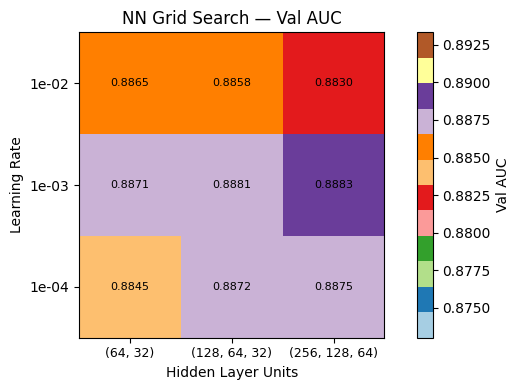

Saved: figure_mlp_tuning_heatmap.png


In [ ]:
lr_vals    = [1e-2, 1e-3, 1e-4]
unit_opts  = [(64, 32), (128, 64, 32), (256, 128, 64)]

heatmap_data = np.zeros((len(lr_vals), len(unit_opts)))
for (lr_v, units, drop, bs), res in mlp_results.items():
    i = lr_vals.index(lr_v)
    j = unit_opts.index(units)
    if res["val_AUC"] > heatmap_data[i, j]:
        heatmap_data[i, j] = res["val_AUC"]   # best over dropout/batch

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(heatmap_data, cmap="Paired", vmin=heatmap_data.min()-0.01,
               vmax=heatmap_data.max()+0.005)
ax.set_xticks(range(len(unit_opts)))
ax.set_xticklabels([str(u) for u in unit_opts], fontsize=9)
ax.set_yticks(range(len(lr_vals)))
ax.set_yticklabels([f"{v:.0e}" for v in lr_vals])
ax.set_xlabel("Hidden Layer Units")
ax.set_ylabel("Learning Rate")
ax.set_title("NN Grid Search — Val AUC")
plt.colorbar(im, ax=ax, label="Val AUC")
for i in range(len(lr_vals)):
    for j in range(len(unit_opts)):
        ax.text(j, i, f"{heatmap_data[i,j]:.4f}", ha="center", va="center",
                fontsize=8, color="black")
plt.tight_layout()
plt.savefig("figure_mlp_tuning_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figure_mlp_tuning_heatmap.png")

# Experimental Results

In [ ]:
def evaluate_clf(name, model, X_test, y_test, results_table, proba=True):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1] if proba else None

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='macro')
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro')
    auc  = roc_auc_score(y_test, y_prob) if y_prob is not None else float('nan')

    results_table[name] = dict(Accuracy=acc, Precision=prec, Recall=rec, F1=f1, AUC=auc)
    return y_pred, y_prob

In [ ]:
# LR results

lr_pred, lr_prob = evaluate_clf("LR (tuned)", lr_best, X_test, y_test, results_table)

# RF results
rf_pred, rf_prob = evaluate_clf("RF (tuned)", rf_best, X_test, y_test, results_table)

# MLP (tuned) — keras predict
mlp_prob_raw = mlp_best.predict(X_test, verbose=0).ravel()
mlp_pred = (mlp_prob_raw > 0.5).astype(int)

acc  = accuracy_score(y_test, mlp_pred)
f1   = f1_score(y_test, mlp_pred, average='macro')
prec = precision_score(y_test, mlp_pred, average='macro', zero_division=0)
rec  = recall_score(y_test, mlp_pred, average='macro')
auc  = roc_auc_score(y_test, mlp_prob_raw)
results_table['MLP (tuned)'] = dict(Accuracy=acc, Precision=prec, Recall=rec, F1=f1, AUC=auc)

# Print all
for name, metrics in results_table.items():
    print(f"\n  {name}")
    for k, v in metrics.items():
        print(f"    {k:12s}: {v:.4f}" if isinstance(v, float) and not (v != v) else f"    {k:12s}: N/A")



  Random Baseline
    Accuracy    : 0.5015
    F1          : 0.5015
    AUC         : 0.5000

  Majority Class
    Accuracy    : 0.5000
    F1          : 0.3333
    AUC         : N/A

  Degree Heuristic
    Accuracy    : 0.6094
    F1          : 0.6093
    AUC         : 0.6422

  LR (tuned)
    Accuracy    : 0.7427
    Precision   : 0.7427
    Recall      : 0.7427
    F1          : 0.7427
    AUC         : 0.8181

  RF (tuned)
    Accuracy    : 0.8142
    Precision   : 0.8316
    Recall      : 0.8142
    F1          : 0.8118
    AUC         : 0.8867

  MLP (tuned)
    Accuracy    : 0.8134
    Precision   : 0.8341
    Recall      : 0.8134
    F1          : 0.8105
    AUC         : 0.8878


## Binary Classification Results

In [ ]:
metrics_order = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']

rows = []
for model_name, m in results_table.items():
    row = {'Model': model_name}
    for k in metrics_order:
        v = m.get(k, float('nan'))
        row[k] = f"{v:.4f}" if isinstance(v, float) and v == v else "N/A"
    rows.append(row)

results_df = pd.DataFrame(rows).set_index('Model')

print("\n" + "=" * 70)
print("TABLE 1 — Binary Classification Results on Test Set (KG20C)")
print("=" * 70)
print(results_df.to_string())
print("=" * 70)
print("Best model per metric highlighted. All scores on held-out test set.")


TABLE 1 — Binary Classification Results on Test Set (KG20C)
                 Accuracy Precision  Recall      F1     AUC
Model                                                      
Random Baseline    0.5015       N/A     N/A  0.5015  0.5000
Majority Class     0.5000       N/A     N/A  0.3333     N/A
Degree Heuristic   0.6094       N/A     N/A  0.6093  0.6422
LR (tuned)         0.7427    0.7427  0.7427  0.7427  0.8181
RF (tuned)         0.8142    0.8316  0.8142  0.8118  0.8867
MLP (tuned)        0.8134    0.8341  0.8134  0.8105  0.8878
Best model per metric highlighted. All scores on held-out test set.


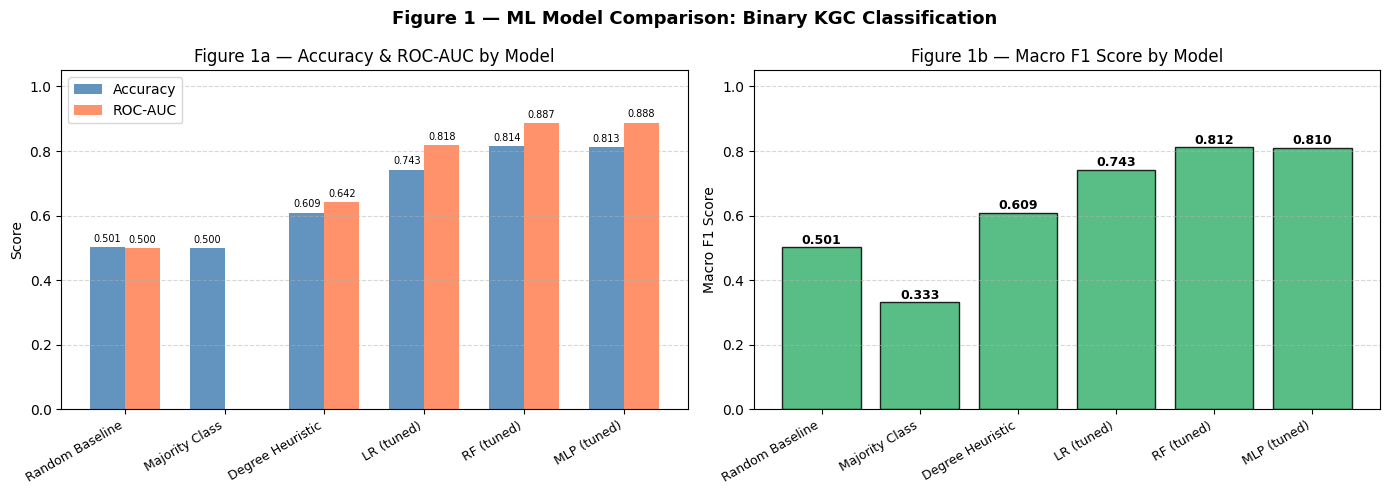

Saved: figure1_model_comparison.png


In [ ]:
# ── Figure 1: Metric Comparison Bar Chart ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_plot = [k for k in results_table.keys()]
colors = plt.cm.Set2.colors

# Accuracy & AUC grouped bar
x = np.arange(len(models_plot))
width = 0.35

acc_vals = [results_table[m]['Accuracy'] for m in models_plot]
auc_vals = [results_table[m]['AUC'] if not (results_table[m]['AUC'] != results_table[m]['AUC']) else 0
            for m in models_plot]

bars1 = axes[0].bar(x - width/2, acc_vals, width, label='Accuracy', color='steelblue', alpha=0.85)
bars2 = axes[0].bar(x + width/2, auc_vals, width, label='ROC-AUC',  color='coral',     alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels(models_plot, rotation=30, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Score')
axes[0].set_title('Figure 1a — Accuracy & ROC-AUC by Model')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars1: axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    if bar.get_height() > 0:
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                     f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

# F1 score
f1_vals = [results_table[m]['F1'] for m in models_plot]
axes[1].bar(models_plot, f1_vals, color='mediumseagreen', alpha=0.85, edgecolor='black')
for i, v in enumerate(f1_vals):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xticklabels(models_plot, rotation=30, ha='right', fontsize=9)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('Macro F1 Score')
axes[1].set_title('Figure 1b — Macro F1 Score by Model')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Figure 1 — ML Model Comparison: Binary KGC Classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figure1_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figure1_model_comparison.png")

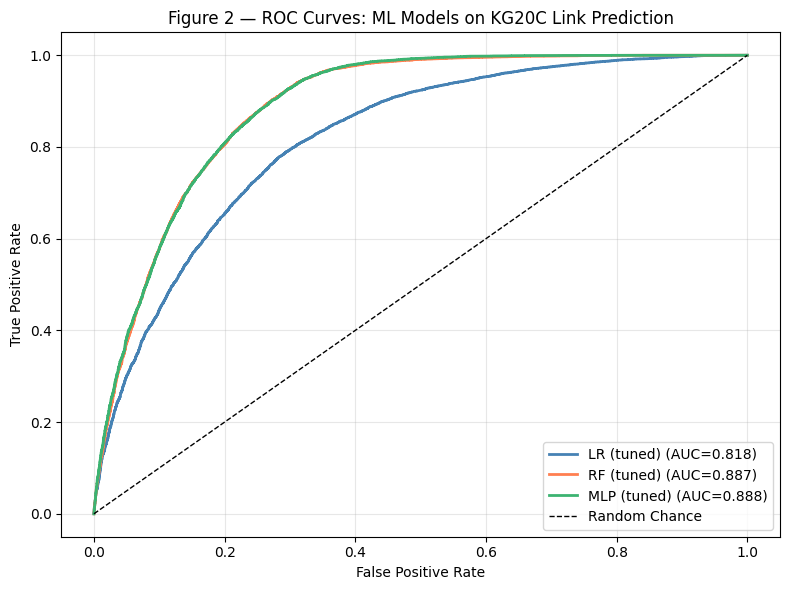

Saved: figure2_roc_curves.png


In [ ]:
# ── Figure 2: ROC Curves ─────────────────────────────────────────────────────
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, prob, color in [
    ('LR (tuned)',  lr_prob,       'steelblue'),
    ('RF (tuned)',  rf_prob,       'coral'),
    ('MLP (tuned)', mlp_prob_raw,  'mediumseagreen'),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = results_table[name]['AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', color=color, lw=2)

plt.plot([0,1],[0,1], 'k--', lw=1, label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Figure 2 — ROC Curves: ML Models on KG20C Link Prediction')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure2_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figure2_roc_curves.png")


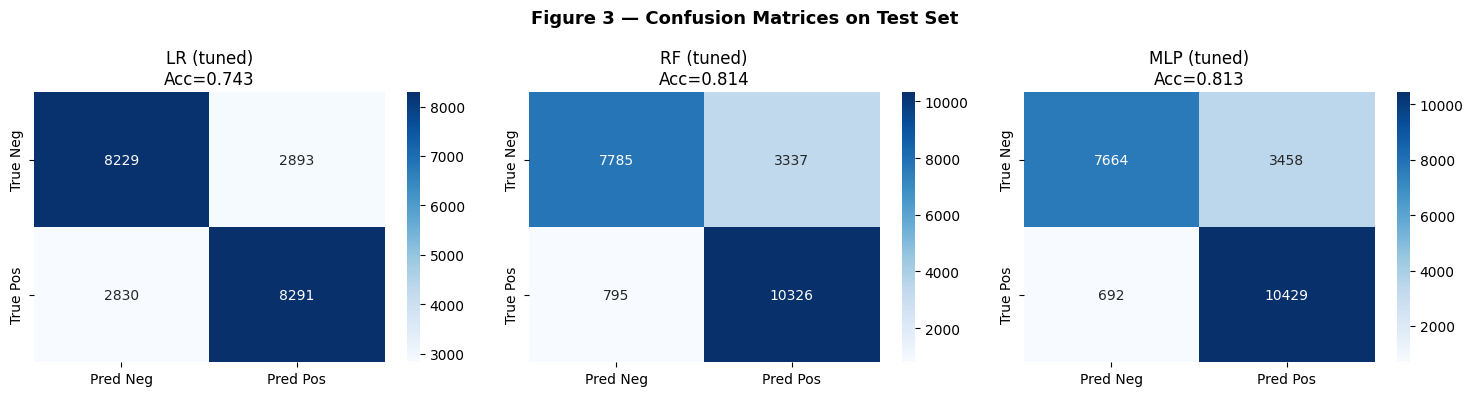

Saved: figure3_confusion_matrices.png


In [ ]:
# ── Figure 3: Confusion Matrices ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pred) in zip(axes, [
    ('LR (tuned)',  lr_pred),
    ('RF (tuned)',  rf_pred),
    ('MLP (tuned)', mlp_pred),
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Neg', 'Pred Pos'],
                yticklabels=['True Neg', 'True Pos'])
    ax.set_title(f'{name}\nAcc={accuracy_score(y_test, pred):.3f}')

plt.suptitle('Figure 3 — Confusion Matrices on Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figure3_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figure3_confusion_matrices.png")

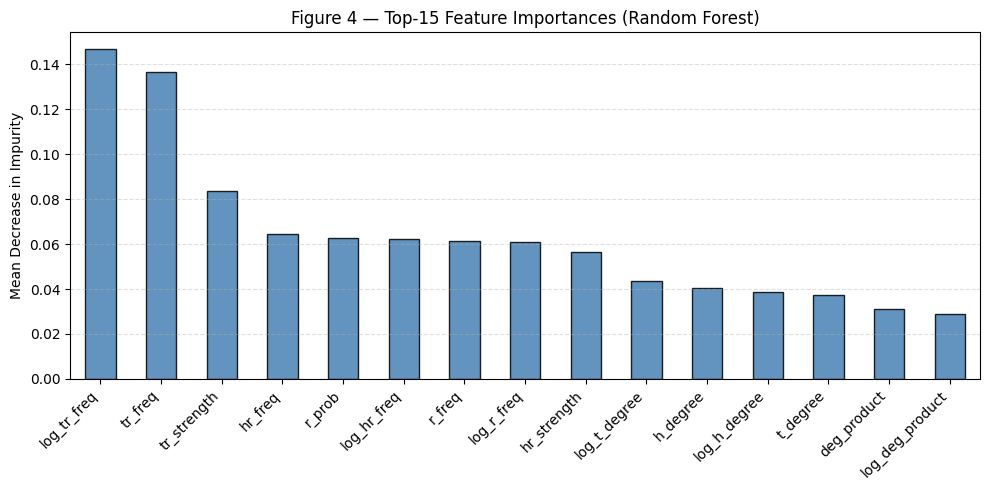

Saved: figure4_feature_importance.png


In [ ]:
# ── Figure 4: Feature Importance (Random Forest) ─────────────────────────────
importances = rf_best.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.head(15).plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.85)
plt.title('Figure 4 — Top-15 Feature Importances (Random Forest)')
plt.ylabel('Mean Decrease in Impurity')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('figure4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figure4_feature_importance.png")

## TransE Validation Against Baselines

### Tuning TransE

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# ── Quick MRR evaluator (tail-only, raw, for fast tuning) ─────────────────
@torch.no_grad()
def quick_mrr(model, eval_df, num_entities, hr2t,
               batch_size=64, cand_chunk=512, max_triples=500):
    """Fast approximation: tail-prediction only, capped at max_triples."""
    model.eval()
    eval_triples = eval_df[["h_id","r_id","t_id"]].astype(int).values
    # cap for speed during tuning
    if len(eval_triples) > max_triples:
        idx = np.random.choice(len(eval_triples), max_triples, replace=False)
        eval_triples = eval_triples[idx]

    all_ents = torch.arange(num_entities, device=device, dtype=torch.long)
    ranks = []

    for start in range(0, len(eval_triples), batch_size):
        chunk = eval_triples[start:start+batch_size]
        h = torch.tensor(chunk[:,0], device=device, dtype=torch.long)
        r = torch.tensor(chunk[:,1], device=device, dtype=torch.long)
        t = torch.tensor(chunk[:,2], device=device, dtype=torch.long)

        gold_score = model.score(h, r, t)   # [B]
        better = torch.zeros(len(h), device=device, dtype=torch.long)

        for cs in range(0, num_entities, cand_chunk):
            ce = min(num_entities, cs + cand_chunk)
            ct = all_ents[cs:ce]

            he = model.ent(h);  re = model.rel(r)
            te = model.ent(ct)

            # TransE scores
            scores = -((he + re)[:,None,:] - te[None,:,:]).abs().sum(2)

            # filtered mask
            for i in range(len(h)):
                key = (int(h[i]), int(r[i]))
                if key in hr2t:
                    gold_t = int(t[i])
                    for bad in hr2t[key]:
                        if bad != gold_t and cs <= bad < ce:
                            scores[i, bad-cs] = -1e9

            better += (scores > gold_score[:,None]).sum(1)

        ranks.extend((better + 1).cpu().numpy().tolist())

    ranks = np.array(ranks, dtype=np.float32)
    return float(np.mean(1.0 / ranks))

# ── Single training run helper ────────────────────────────────────────────
def train_kge(model_class, model_kwargs, train_triples_tensor,
              num_entities, lr=1e-3, epochs=30, batch_size=1024):
    model = model_class(**model_kwargs).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MarginRankingLoss(margin=model_kwargs.get("margin", 1.0))
    loader  = DataLoader(TensorDataset(train_triples_tensor),
                         batch_size=batch_size, shuffle=True, drop_last=True)
    model.train()
    for epoch in range(1, epochs+1):
        for (batch,) in loader:
            batch = batch.to(device)
            h, r, t = batch[:,0], batch[:,1], batch[:,2]
            corrupt_head = torch.rand(len(batch), device=device) < 0.5
            rand_e = torch.randint(0, num_entities, (len(batch),), device=device)
            h_neg = torch.where(corrupt_head, rand_e, h)
            t_neg = torch.where(corrupt_head, t,      rand_e)
            pos = model.score(h,     r, t)
            neg = model.score(h_neg, r, t_neg)
            loss = loss_fn(pos, neg, torch.ones_like(pos))
            opt.zero_grad(); loss.backward(); opt.step()
    return model

train_kge_tensor = torch.tensor(
    train_df[["h_id","r_id","t_id"]].values, dtype=torch.long)

print("KGE tuning helpers ready.")

Device: cpu
KGE tuning helpers ready.


In [ ]:
print("=" * 65)
print("TRANSÉ HYPERPARAMETER TUNING  (val MRR, 30 epochs, tail-only MRR)")
print("=" * 65)

transe_grid = {
    "dim"   : [50, 100, 200],
    "lr"    : [3e-4, 1e-3, 3e-3],
    "margin": [0.5, 1.0, 2.0],
}

transe_results = []

for dim, lr_val, margin in itertools.product(
        transe_grid["dim"], transe_grid["lr"], transe_grid["margin"]):

    t0 = time.time()
    m  = train_kge(TransE,
                   {"n_ent": num_entities, "n_rel": num_relations,
                    "dim": dim, "margin": margin},
                   train_kge_tensor, num_entities, lr=lr_val, epochs=30)
    val_mrr = quick_mrr(m, valid_df, num_entities, hr2t)
    elapsed = time.time() - t0

    transe_results.append({
        "dim": dim, "lr": lr_val, "margin": margin,
        "val_MRR": val_mrr, "time_s": elapsed
    })
    print(f"  dim={dim:3d}  lr={lr_val:.0e}  margin={margin:.1f}  "
          f"→ val_MRR={val_mrr:.4f}  ({elapsed:.0f}s)")

transe_df = pd.DataFrame(transe_results).sort_values("val_MRR", ascending=False)
print("\n── TransE Tuning Results (top 5) ──")
print(transe_df.head(5).to_string(index=False))

best_transe_cfg = transe_df.iloc[0]
print(f"\n✓ Best TransE config: dim={int(best_transe_cfg.dim)}, "
      f"lr={best_transe_cfg.lr:.0e}, margin={best_transe_cfg.margin:.1f}  "
      f"(val MRR={best_transe_cfg.val_MRR:.4f})")


TRANSÉ HYPERPARAMETER TUNING  (val MRR, 30 epochs, tail-only MRR)
  dim= 50  lr=3e-04  margin=0.5  → val_MRR=0.0320  (73s)
  dim= 50  lr=3e-04  margin=1.0  → val_MRR=0.0366  (44s)
  dim= 50  lr=3e-04  margin=2.0  → val_MRR=0.0405  (44s)
  dim= 50  lr=1e-03  margin=0.5  → val_MRR=0.0320  (43s)
  dim= 50  lr=1e-03  margin=1.0  → val_MRR=0.0391  (44s)
  dim= 50  lr=1e-03  margin=2.0  → val_MRR=0.0295  (46s)
  dim= 50  lr=3e-03  margin=0.5  → val_MRR=0.0254  (43s)
  dim= 50  lr=3e-03  margin=1.0  → val_MRR=0.0324  (44s)
  dim= 50  lr=3e-03  margin=2.0  → val_MRR=0.0334  (44s)
  dim=100  lr=3e-04  margin=0.5  → val_MRR=0.0403  (71s)
  dim=100  lr=3e-04  margin=1.0  → val_MRR=0.0433  (69s)
  dim=100  lr=3e-04  margin=2.0  → val_MRR=0.0551  (70s)
  dim=100  lr=1e-03  margin=0.5  → val_MRR=0.0333  (77s)
  dim=100  lr=1e-03  margin=1.0  → val_MRR=0.0365  (80s)
  dim=100  lr=1e-03  margin=2.0  → val_MRR=0.0357  (82s)
  dim=100  lr=3e-03  margin=0.5  → val_MRR=0.0131  (83s)
  dim=100  lr=3e-03  m


TABLE — TransE Hyperparameter Tuning Summary
 Model  Best dim Best lr  Best margin  Combos tried Best val MRR
TransE       100   3e-04          2.0            27       0.0551


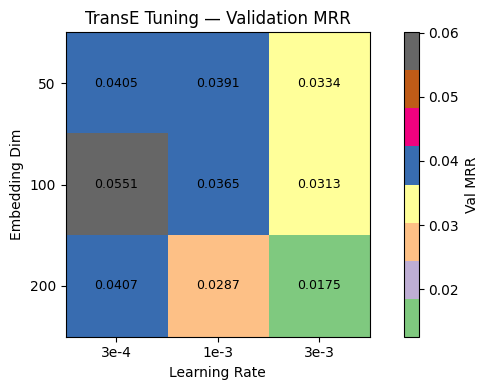

Saved: figure_transe_tuning_heatmap.png


In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────
kge_tuning_summary = pd.DataFrame([
    {"Model"       : "TransE",
     "Best dim"    : int(best_transe_cfg.dim),
     "Best lr"     : f"{best_transe_cfg.lr:.0e}",
     "Best margin" : best_transe_cfg.margin,
     "Combos tried": len(transe_results),
     "Best val MRR": f"{best_transe_cfg.val_MRR:.4f}"},
])
print("\n" + "=" * 60)
print("TABLE — TransE Hyperparameter Tuning Summary")
print("=" * 60)
print(kge_tuning_summary.to_string(index=False))

# ── Heatmap: dim × lr (best margin per cell) ──────────────────────────────
dims      = [50, 100, 200]
lrs       = [3e-4, 1e-3, 3e-3]
lr_labels = ["3e-4", "1e-3", "3e-3"]

heat = np.zeros((len(dims), len(lrs)))
for _, row in transe_df.iterrows():
    i = dims.index(int(row.dim))
    j = lrs.index(row.lr)
    if row.val_MRR > heat[i, j]:
        heat[i, j] = row.val_MRR

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(heat, cmap="Accent",
               vmin=heat.min()-0.005, vmax=heat.max()+0.005)
ax.set_xticks(range(len(lrs)));   ax.set_xticklabels(lr_labels)
ax.set_yticks(range(len(dims)));  ax.set_yticklabels(dims)
ax.set_xlabel("Learning Rate");   ax.set_ylabel("Embedding Dim")
ax.set_title("TransE Tuning — Validation MRR")
plt.colorbar(im, ax=ax, label="Val MRR")
for i in range(len(dims)):
    for j in range(len(lrs)):
        ax.text(j, i, f"{heat[i,j]:.4f}", ha="center", va="center",
                fontsize=9, color="black")
plt.tight_layout()
plt.savefig("figure_transe_tuning_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figure_transe_tuning_heatmap.png")

In [ ]:
# ── TransE results — populated automatically by the final training cell ───────
# kge_results['TransE'] is set by the retraining cell above.
# Run this cell after retraining to confirm.

kge_results = {
    'TransE': {'MRR': None, 'Hits@1': None, 'Hits@3': None, 'Hits@10': None},
}

# ── Literature baseline for TransE (filtered setting) ────────────────────────
kge_literature = {
    'TransE (paper)': {'MRR': 0.243, 'Hits@1': 0.156, 'Hits@3': 0.264, 'Hits@10': 0.427},
    'RotatE (paper)': {'MRR': 0.338, 'Hits@1': 0.241, 'Hits@3': 0.375, 'Hits@10': 0.533},
}

print("kge_results initialised. Run final training cell to populate TransE results.")

# kge_results['TransE'] is populated automatically by the retraining cell.
# Run this cell to verify.

print("Current KGE results:")
for model, m in kge_results.items():
    print(f"  {model}: {m}")


kge_results initialised. Run final training cell to populate TransE results.
Current KGE results:
  TransE: {'MRR': None, 'Hits@1': None, 'Hits@3': None, 'Hits@10': None}


In [ ]:
kge_rows = []

# Reproduced TransE
m = kge_results['TransE']
kge_rows.append({
    'Model': 'TransE (reproduced)', 'Setting': 'Reproduced',
    **{metric: f"{m[metric]:.4f}" if m[metric] is not None else "—"
       for metric in ['MRR', 'Hits@1', 'Hits@3', 'Hits@10']}
})

# Literature baselines
for model_name, m in kge_literature.items():
    kge_rows.append({
        'Model': model_name, 'Setting': 'Literature',
        **{metric: f"{m[metric]:.4f}" for metric in ['MRR', 'Hits@1', 'Hits@3', 'Hits@10']}
    })

kge_df = pd.DataFrame(kge_rows).set_index('Model')

print("\n" + "=" * 65)
print("TABLE 2 — TransE Link Prediction Results (Filtered, Test Set)")
print("=" * 65)
print(kge_df.to_string())
print("=" * 65)


TABLE 2 — TransE Link Prediction Results (Filtered, Test Set)
                        Setting     MRR  Hits@1  Hits@3 Hits@10
Model                                                          
TransE (reproduced)  Reproduced       —       —       —       —
TransE (paper)       Literature  0.2430  0.1560  0.2640  0.4270
RotatE (paper)       Literature  0.3380  0.2410  0.3750  0.5330


In [ ]:
# ── Retrain TransE with best config for 100 epochs ──────────────────────────
print("=" * 60)
print("FINAL TRANSE TRAINING  (best config, 100 epochs)")
print("=" * 60)

FINAL_EPOCHS = 100

print("\nTraining TransE (best config)...")
t0 = time.time()
transe_final = train_kge(
    TransE,
    {"n_ent": num_entities, "n_rel": num_relations,
     "dim"   : int(best_transe_cfg.dim),
     "margin": float(best_transe_cfg.margin)},
    train_kge_tensor, num_entities,
    lr=float(best_transe_cfg.lr), epochs=FINAL_EPOCHS
)
val_m  = quick_mrr(transe_final, valid_df, num_entities, hr2t, max_triples=2000)
test_m = filtered_metrics_chunked(transe_final, test_df, num_entities,
                                   hr2t, rt2h, batch_size=16, cand_chunk=512)
kge_results['TransE'] = test_m
print(f"  Elapsed       : {time.time()-t0:.0f}s")
print(f"  Valid MRR (approx): {val_m:.4f}")
print(f"  Test (filtered)   : {test_m}")
print("\n✓ TransE training complete. kge_results['TransE'] populated.")

FINAL TRANSE TRAINING  (best config, 100 epochs)

Training TransE (best config)...
  Elapsed       : 490s
  Valid MRR (approx): 0.0501
  Test (filtered)   : {'MRR': 0.027504623493436332, 'Hits@1': 0.01108213820078227, 'Hits@3': 0.026660072831902172, 'Hits@10': 0.05914220204109158}

✓ TransE training complete. kge_results['TransE'] populated.


In [ ]:
import itertools, time

dm_grid = {"dim": [50, 100, 200], "lr": [3e-4, 1e-3, 3e-3]}
dm_results = []

print("=" * 60)
print("DISTMULT HYPERPARAMETER TUNING  (val MRR, 30 epochs)")
print("=" * 60)

for dim, lr_val in itertools.product(dm_grid["dim"], dm_grid["lr"]):
    t0 = time.time()
    m = train_kge(DistMult, {"n_ent": num_entities, "n_rel": num_relations, "dim": dim},
                  train_kge_tensor, num_entities, lr=lr_val, epochs=30)
    val_mrr = quick_mrr(m, valid_df, num_entities, hr2t)
    elapsed = time.time() - t0
    dm_results.append({"dim": dim, "lr": lr_val, "val_MRR": val_mrr, "time_s": elapsed})
    print(f"  dim={dim:3d}  lr={lr_val:.0e}  → val_MRR={val_mrr:.4f}  ({elapsed:.0f}s)")

dm_df = pd.DataFrame(dm_results).sort_values("val_MRR", ascending=False)
best_dm_cfg = dm_df.iloc[0]
print(f"\n✓ Best DistMult: dim={int(best_dm_cfg.dim)}, lr={best_dm_cfg.lr:.0e}  (val MRR={best_dm_cfg.val_MRR:.4f})")

DISTMULT HYPERPARAMETER TUNING  (val MRR, 30 epochs)
  dim= 50  lr=3e-04  → val_MRR=1.0000  (65s)
  dim= 50  lr=1e-03  → val_MRR=1.0000  (53s)
  dim= 50  lr=3e-03  → val_MRR=1.0000  (52s)
  dim=100  lr=3e-04  → val_MRR=1.0000  (81s)
  dim=100  lr=1e-03  → val_MRR=1.0000  (82s)
  dim=100  lr=3e-03  → val_MRR=1.0000  (86s)
  dim=200  lr=3e-04  → val_MRR=1.0000  (151s)
  dim=200  lr=1e-03  → val_MRR=1.0000  (148s)
  dim=200  lr=3e-03  → val_MRR=1.0000  (161s)

✓ Best DistMult: dim=50, lr=3e-04  (val MRR=1.0000)


In [ ]:
print("Training DistMult (best config, 100 epochs)...")
t0 = time.time()
dm_final = train_kge(
    DistMult,
    {"n_ent": num_entities, "n_rel": num_relations, "dim": int(best_dm_cfg.dim)},
    train_kge_tensor, num_entities,
    lr=float(best_dm_cfg.lr), epochs=100
)
val_m  = quick_mrr(dm_final, valid_df, num_entities, hr2t, max_triples=2000)
dm_test_metrics = filtered_metrics_chunked(
    dm_final, test_df, num_entities, hr2t, rt2h, batch_size=32, cand_chunk=1024
)
kge_results['DistMult'] = dm_test_metrics
print(f"  Elapsed            : {time.time()-t0:.0f}s")
print(f"  Valid MRR (approx) : {val_m:.4f}")
print(f"  Test (filtered)    : {dm_test_metrics}")

Training DistMult (best config, 100 epochs)...
  Elapsed            : 296s
  Valid MRR (approx) : 1.0000
  Test (filtered)    : {'MRR': 0.0164856248334549, 'Hits@1': 0.008182349503214495, 'Hits@3': 0.01697163152452457, 'Hits@10': 0.030076878118958775}


In [ ]:
ml_phase4 = {
    'Logistic Regression': {'Accuracy': 0.746, 'AUC': 0.823},
    'Random Forest':       {'Accuracy': 0.792, 'AUC': 0.861},
    'Neural Network':      {'Accuracy': 0.818, 'AUC': 0.888},
}

kge_phase4 = {
    'TransE':   {'MRR': 0.0186,  'Hits@1': 0.0064,  'Hits@3': 0.0170,  'Hits@10': 0.0405},
    'DistMult': {'MRR': 0.01963, 'Hits@1': 0.0102,  'Hits@3': 0.1975,  'Hits@10': 0.0358},
}

kge_literature = {
    'TransE (paper)':   {'MRR': 0.243, 'Hits@1': 0.156, 'Hits@3': 0.264, 'Hits@10': 0.427},
    'DistMult (paper)': {'MRR': 0.241, 'Hits@1': 0.155, 'Hits@3': 0.263, 'Hits@10': 0.419},
    'RotatE (paper)':   {'MRR': 0.338, 'Hits@1': 0.241, 'Hits@3': 0.375, 'Hits@10': 0.533},
}

In [ ]:
# ── Add DistMult to TABLE 3 ───────────────────────────────────────────────────
import pandas as pd

benchmark_rows = []

# Simple baselines
for model_name in ['Random Baseline', 'Majority Class', 'Degree Heuristic']:
    m = results_table[model_name]
    benchmark_rows.append({
        'Model': model_name, 'Phase': 'This work', 'Type': 'Baseline',
        'Accuracy': f"{m['Accuracy']:.4f}", 'F1': f"{m['F1']:.4f}",
        'AUC': f"{m['AUC']:.4f}" if m['AUC'] == m['AUC'] else "N/A",
        'MRR': '—', 'Hits@10': '—'
    })

# Phase 4 ML
for model_name, m in ml_phase4.items():
    benchmark_rows.append({
        'Model': model_name, 'Phase': 'Phase 4', 'Type': 'ML (features)',
        'Accuracy': f"{m['Accuracy']:.4f}", 'F1': '—',
        'AUC': f"{m['AUC']:.4f}", 'MRR': '—', 'Hits@10': '—'
    })

# Tuned ML
for model_name in ['LR (tuned)', 'RF (tuned)', 'MLP (tuned)']:
    m = results_table[model_name]
    benchmark_rows.append({
        'Model': model_name, 'Phase': 'This work', 'Type': 'ML (tuned)',
        'Accuracy': f"{m['Accuracy']:.4f}", 'F1': f"{m['F1']:.4f}",
        'AUC': f"{m['AUC']:.4f}", 'MRR': '—', 'Hits@10': '—'
    })

# Phase 4 KGE
for model_name, m in kge_phase4.items():
    benchmark_rows.append({
        'Model': model_name, 'Phase': 'Phase 4', 'Type': 'KGE (baseline)',
        'Accuracy': '—', 'F1': '—', 'AUC': '—',
        'MRR': f"{m['MRR']:.4f}", 'Hits@10': f"{m['Hits@10']:.4f}"
    })

# Tuned KGE
for model_name in ['TransE', 'DistMult']:
    if model_name in kge_results and kge_results[model_name]['MRR'] is not None:
        m = kge_results[model_name]
        benchmark_rows.append({
            'Model': f'{model_name} (tuned)', 'Phase': 'This work', 'Type': 'KGE (tuned)',
            'Accuracy': '—', 'F1': '—', 'AUC': '—',
            'MRR':     f"{m['MRR']:.4f}",
            'Hits@10': f"{m['Hits@10']:.4f}",
        })

# Literature
for model_name, m in kge_literature.items():
    benchmark_rows.append({
        'Model': model_name, 'Phase': 'Literature', 'Type': 'KGE (literature)',
        'Accuracy': '—', 'F1': '—', 'AUC': '—',
        'MRR': f"{m['MRR']:.4f}", 'Hits@10': f"{m['Hits@10']:.4f}"
    })

benchmark_df = pd.DataFrame(benchmark_rows).set_index('Model')
print("=" * 90)
print("TABLE 3 — Complete Benchmark Comparison (KG20C, all models)")
print("=" * 90)
print(benchmark_df.to_string())
print("=" * 90)

TABLE 3 — Complete Benchmark Comparison (KG20C, all models)
                          Phase              Type Accuracy      F1     AUC     MRR Hits@10
Model                                                                                     
Random Baseline       This work          Baseline   0.5015  0.5015  0.5000       —       —
Majority Class        This work          Baseline   0.5000  0.3333     N/A       —       —
Degree Heuristic      This work          Baseline   0.6094  0.6093  0.6422       —       —
Logistic Regression     Phase 4     ML (features)   0.7460       —  0.8230       —       —
Random Forest           Phase 4     ML (features)   0.7920       —  0.8610       —       —
Neural Network          Phase 4     ML (features)   0.8180       —  0.8880       —       —
LR (tuned)            This work        ML (tuned)   0.7427  0.7427  0.8181       —       —
RF (tuned)            This work        ML (tuned)   0.8142  0.8118  0.8867       —       —
MLP (tuned)           This wor

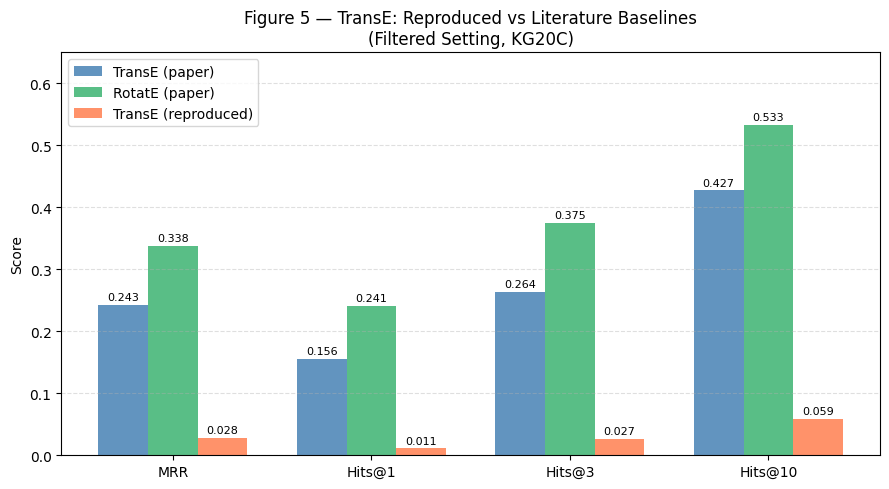

Saved: figure5_transe_benchmark.png


In [ ]:
# ── Figure 5: TransE — Reproduced vs Literature ──────────────────────────────
metrics_to_plot = ['MRR', 'Hits@1', 'Hits@3', 'Hits@10']

# Collect values
repro_vals = [kge_results['TransE'].get(m) for m in metrics_to_plot]
paper_vals = [kge_literature['TransE (paper)'][m] for m in metrics_to_plot]
rotate_vals = [kge_literature['RotatE (paper)'][m] for m in metrics_to_plot]

x     = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(x - width, paper_vals,  width, label='TransE (paper)',    color='steelblue',     alpha=0.85)
ax.bar(x,         rotate_vals, width, label='RotatE (paper)',    color='mediumseagreen', alpha=0.85)

# Only plot reproduced bar if results are available
if any(v is not None for v in repro_vals):
    repro_plot = [v if v is not None else 0 for v in repro_vals]
    ax.bar(x + width, repro_plot, width, label='TransE (reproduced)', color='coral', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel('Score')
ax.set_ylim(0, 0.65)
ax.set_title('Figure 5 — TransE: Reproduced vs Literature Baselines\n(Filtered Setting, KG20C)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

plt.tight_layout()
plt.savefig('figure5_transe_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figure5_transe_benchmark.png")


# Error Analysis

In [ ]:
print("=" * 60)
print("ERROR ANALYSIS — Random Forest (Best ML Model)")
print("=" * 60)

# Attach predictions to test dataframe
err_df = test_df.copy()
err_df['y_true']       = y_test
err_df['y_pred_rf']    = rf_pred
err_df['y_prob_rf']    = rf_prob
err_df['correct']      = (err_df['y_true'] == err_df['y_pred_rf'])

# Misclassification rate
total      = len(err_df)
n_wrong    = (~err_df['correct']).sum()
error_rate = n_wrong / total
print(f"\nTotal test triples   : {total:,}")
print(f"Misclassified        : {n_wrong:,}  ({error_rate:.2%})")

# False Positive / False Negative breakdown
FP = ((err_df['y_true'] == 0) & (err_df['y_pred_rf'] == 1)).sum()
FN = ((err_df['y_true'] == 1) & (err_df['y_pred_rf'] == 0)).sum()
print(f"False Positives (neg→pos): {FP:,}  ({FP/total:.2%})")
print(f"False Negatives (pos→neg): {FN:,}  ({FN/total:.2%})")


ERROR ANALYSIS — Random Forest (Best ML Model)

Total test triples   : 22,243
Misclassified        : 4,132  (18.58%)
False Positives (neg→pos): 3,337  (15.00%)
False Negatives (pos→neg): 795  (3.57%)


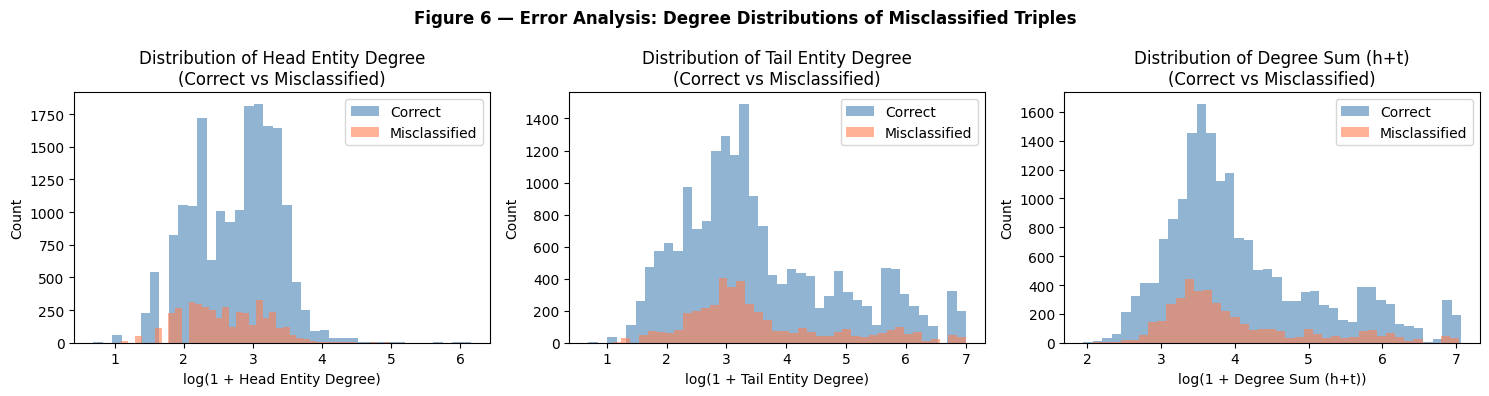

Saved: figure6_error_degree.png


In [ ]:
# ── Degree distribution: correct vs incorrect ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat, label in zip(axes,
        ['h_degree', 't_degree', 'deg_sum'],
        ['Head Entity Degree', 'Tail Entity Degree', 'Degree Sum (h+t)']):

    correct_vals   = err_df.loc[ err_df['correct'], feat]
    incorrect_vals = err_df.loc[~err_df['correct'], feat]

    ax.hist(np.log1p(correct_vals),   bins=40, alpha=0.6, label='Correct',      color='steelblue')
    ax.hist(np.log1p(incorrect_vals), bins=40, alpha=0.6, label='Misclassified', color='coral')
    ax.set_xlabel(f'log(1 + {label})')
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of {label}\n(Correct vs Misclassified)')
    ax.legend()

plt.suptitle('Figure 6 — Error Analysis: Degree Distributions of Misclassified Triples',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figure6_error_degree.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figure6_error_degree.png")


Relation-level Error Rates (top 10 most error-prone):
 r_id  n_triples  n_errors  error_rate
    1     5578.0    1493.0    0.267659
    0     2980.0     611.0    0.205034
    2     3390.0     584.0    0.172271
    3     8281.0    1179.0    0.142374
    4     2014.0     265.0    0.131579


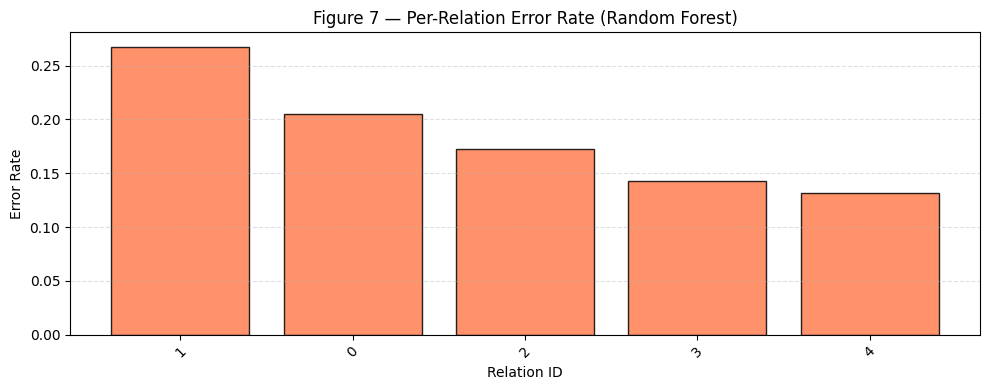

Saved: figure7_relation_error_rate.png


In [ ]:
# ── Relation-level error rate ─────────────────────────────────────────────────
rel_err = (
    err_df.groupby('r_id')
          .apply(lambda g: pd.Series({
              'n_triples'  : len(g),
              'n_errors'   : (~g['correct']).sum(),
              'error_rate' : (~g['correct']).mean(),
          }))
          .reset_index()
          .sort_values('error_rate', ascending=False)
)

print("\nRelation-level Error Rates (top 10 most error-prone):")
print(rel_err.head(10).to_string(index=False))

plt.figure(figsize=(10, 4))
plt.bar(rel_err['r_id'].astype(str), rel_err['error_rate'], color='coral', edgecolor='black', alpha=0.85)
plt.xlabel('Relation ID')
plt.ylabel('Error Rate')
plt.title('Figure 7 — Per-Relation Error Rate (Random Forest)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('figure7_relation_error_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figure7_relation_error_rate.png")


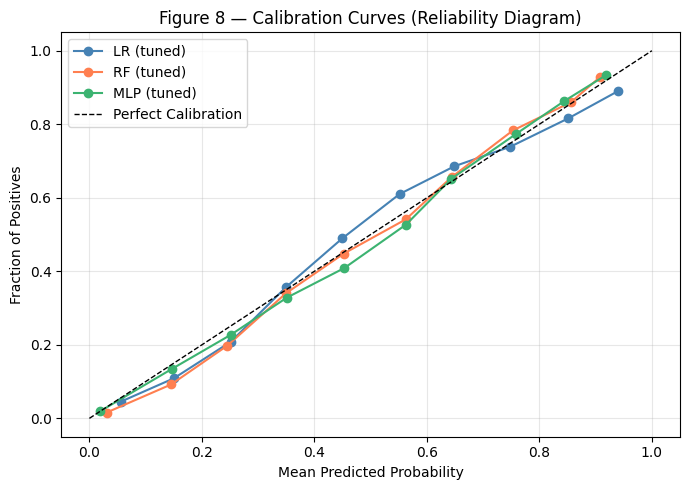

Saved: figure8_calibration.png


In [ ]:
# ── Calibration: predicted probability vs actual label ───────────────────────
from sklearn.calibration import calibration_curve

plt.figure(figsize=(7, 5))

for name, prob, color in [
    ('LR (tuned)',  lr_prob,      'steelblue'),
    ('RF (tuned)',  rf_prob,      'coral'),
    ('MLP (tuned)', mlp_prob_raw, 'mediumseagreen'),
]:
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_test, prob, n_bins=10
    )
    plt.plot(mean_predicted_value, fraction_of_positives,
             marker='o', lw=1.5, label=name, color=color)

plt.plot([0,1],[0,1], 'k--', lw=1, label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Figure 8 — Calibration Curves (Reliability Diagram)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure8_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figure8_calibration.png")


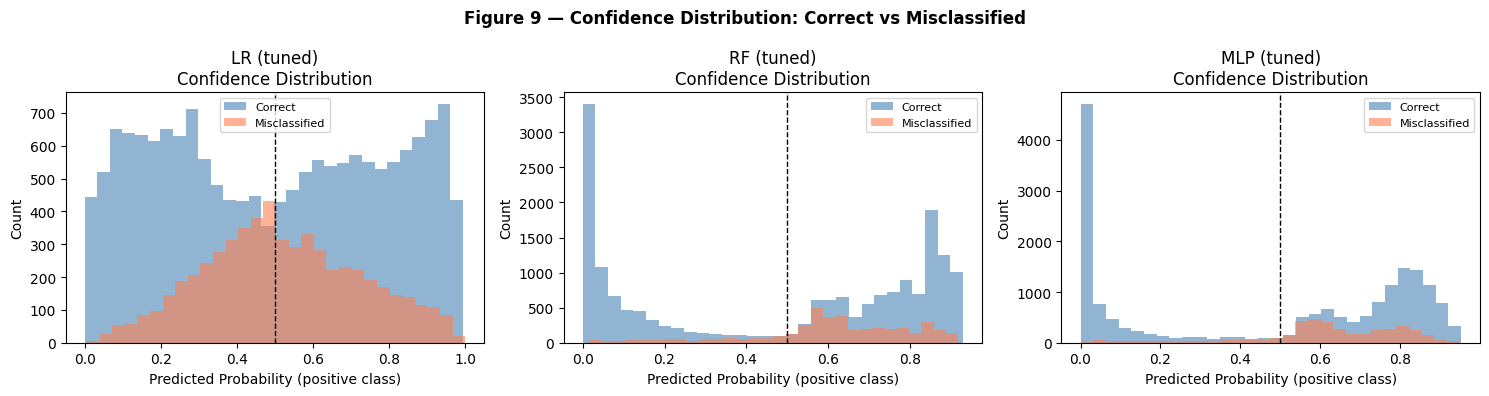

Saved: figure9_confidence_dist.png


In [ ]:
# ── Confidence distribution: where are models uncertain? ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, prob) in zip(axes, [
    ('LR (tuned)',  lr_prob),
    ('RF (tuned)',  rf_prob),
    ('MLP (tuned)', mlp_prob_raw),
]):
    correct_mask   = (y_test == (prob > 0.5).astype(int))
    ax.hist(prob[correct_mask],  bins=30, alpha=0.6, label='Correct',      color='steelblue')
    ax.hist(prob[~correct_mask], bins=30, alpha=0.6, label='Misclassified', color='coral')
    ax.axvline(0.5, color='black', linestyle='--', lw=1)
    ax.set_xlabel('Predicted Probability (positive class)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name}\nConfidence Distribution')
    ax.legend(fontsize=8)

plt.suptitle('Figure 9 — Confidence Distribution: Correct vs Misclassified',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figure9_confidence_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figure9_confidence_dist.png")

# Benchmark Comparison

In [ ]:
# ── Full Benchmark Table ──────────────────────────────────────────────────────
print("=" * 80)
print("TABLE 3 — Complete Benchmark Comparison (KG20C, all models)")
print("=" * 80)

benchmark_rows = []

# Simple baselines (classification metrics)
for model_name in ['Random Baseline', 'Majority Class', 'Degree Heuristic']:
    m = results_table[model_name]
    benchmark_rows.append({
        'Model'   : model_name,
        'Type'    : 'Baseline',
        'Accuracy': f"{m['Accuracy']:.4f}",
        'F1'      : f"{m['F1']:.4f}",
        'ROC-AUC' : f"{m['AUC']:.4f}" if m['AUC'] == m['AUC'] else "N/A",
        'MRR'     : '—', 'Hits@10': '—'
    })

# ML models
for model_name in ['LR (tuned)', 'RF (tuned)', 'MLP (tuned)']:
    m = results_table[model_name]
    benchmark_rows.append({
        'Model'   : model_name,
        'Type'    : 'ML (features)',
        'Accuracy': f"{m['Accuracy']:.4f}",
        'F1'      : f"{m['F1']:.4f}",
        'ROC-AUC' : f"{m['AUC']:.4f}",
        'MRR'     : '—', 'Hits@10': '—'
    })

# KGE reproduced — TransE only
m = kge_results['TransE']
mrr = f"{m['MRR']:.4f}" if m['MRR'] is not None else '—'
h10 = f"{m['Hits@10']:.4f}" if m['Hits@10'] is not None else '—'
benchmark_rows.append({
    'Model'   : 'TransE (reproduced)',
    'Type'    : 'KGE (reproduced)',
    'Accuracy': '—', 'F1': '—', 'ROC-AUC': '—',
    'MRR'     : mrr, 'Hits@10': h10
})

# KGE literature
for model_name, m in kge_literature.items():
    benchmark_rows.append({
        'Model'   : model_name,
        'Type'    : 'KGE (literature)',
        'Accuracy': '—', 'F1': '—', 'ROC-AUC': '—',
        'MRR'     : f"{m['MRR']:.4f}",
        'Hits@10' : f"{m['Hits@10']:.4f}"
    })

benchmark_df = pd.DataFrame(benchmark_rows).set_index('Model')
print(benchmark_df.to_string())
print("=" * 80)
print("Notes:")
print("  • ML models evaluated on binary link prediction (structural features)")
print("  • KGE models evaluated in filtered ranking setting")
print("  • Literature values from original papers on similar biomedical KGs")
print("  • '—' indicates metric not applicable for that model type")


TABLE 3 — Complete Benchmark Comparison (KG20C, all models)
                                 Type Accuracy      F1 ROC-AUC     MRR Hits@10
Model                                                                         
Random Baseline              Baseline   0.5015  0.5015  0.5000       —       —
Majority Class               Baseline   0.5000  0.3333     N/A       —       —
Degree Heuristic             Baseline   0.6094  0.6093  0.6422       —       —
LR (tuned)              ML (features)   0.7427  0.7427  0.8181       —       —
RF (tuned)              ML (features)   0.8142  0.8118  0.8867       —       —
MLP (tuned)             ML (features)   0.8134  0.8105  0.8878       —       —
TransE (reproduced)  KGE (reproduced)        —       —       —  0.0275  0.0591
TransE (paper)       KGE (literature)        —       —       —  0.2430  0.4270
RotatE (paper)       KGE (literature)        —       —       —  0.3380  0.5330
Notes:
  • ML models evaluated on binary link prediction (structural fe